# Гибридная рекомендательная система для книг
## Цель проекта
Создание гибридной рекомендательной системы на реальном датасете книжных рейтингов с использованием современных подходов:
контентной фильтрации (TF-IDF, SBERT),
коллаборативной фильтрации (ALS),
векторного поиска (Qdrant),
нейросетевых эмбеддингов (DSSM),
а также методов интерпретации и визуализации.

### Ключевая цель 
выстроить архитектурно понятную и инженерно обоснованную систему, приближенную к реальным сценариям работы рекомендательных платформ.

## Описание данных
Использован датасет Goodbooks-10k:
10 000 книг
53 424 пользователя
6 000 000+ рейтингов
Каждая книга содержит:
title, authors, genres, description, image_url
числовые признаки: количество оценок (ratings_count), средняя оценка (avg_rating)

## Структура текущего ноутбука
В этом ноутбуке пошагово реализованы все этапы гибридной рекомендательной системы, без необходимости переключения между разными файлами:
Подготовка данных и контентные эмбеддинги
Построение user–item матрицы и ALS
Векторная база Qdrant с метаинформацией о книгах
Генерация кандидатов (ALS + Qdrant)
Ранжирование кандидатов (CatBoost, Random Forest, DSSM)
Интерпретация результатов (SHAP, кластеризация, визуализация)
Streamlit-интерфейс

## Архитектура проекта и окружения
Для реализации используются разные окружения:
recsys_env — основное окружение для sklearn, CatBoost, ALS и визуализации
dssm_env — TensorFlow/DeepMatch для нейросетевых эмбеддингов
qdrant_container — Docker-контейнер с сервером Qdrant
streamlit_env - окружение для работы с Streamlit

Данные передаются между этапами через сохранённые артефакты:
./data/ — эмбеддинги, взаимодействия, мапперы
./models/ — обученные модели и вектора
./qdrant/ — данные, отправленные в векторную базу

## Ограничения по ресурсам
Проект разрабатывается на машине с 32 ГБ ОЗУ. Для стабильной работы:
используется отбор топ-50 000 пользователей и книг,
вычислительно тяжёлые модели применяются точечно,
не дублируются этапы обучения, если возможна загрузка ранее сохранённых объектов.
## В этом ноутбуке 
все этапы идут последовательно, без внешних зависимостей от других файлов. Это обеспечивает удобство анализа, визуализации, повторного запуска и публикации на GitHub. готовую для демонстрации, дообучения, анализа и публикации.


## Базовый блок: импорты

### Окружение: recsys_env
Используется для ALS, CatBoost, контентной модели, метрик и кластеризации.
### Окружение: qdrant_container
Используется для работы с векторной базой Qdrant через API.

In [56]:
# Основное
import json
import csv
import os
import gc
import warnings
import numpy as np
import pandas as pd
import time
from collections import defaultdict, Counter
from pathlib import Path

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Работа с текстом
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# ML-модели и метрики
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, ndcg_score
)
from sklearn.preprocessing import OneHotEncoder
from sentence_transformers import SentenceTransformer
import torch

# Boosting-модель
from catboost import CatBoostClassifier

# Кластеризация
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from umap import UMAP

# Работа с ALS
import scipy.sparse as sparse
from implicit.als import AlternatingLeastSquares

# Загрузка/сохранение
import pickle
import joblib

# SHAP (для CatBoost)
import shap

# Прогресс-бар
from tqdm import tqdm

# Парсинг
import requests
import xml.etree.ElementTree as ET
from isbnlib import is_isbn10, is_isbn13
from urllib.parse import quote_plus

## Блок загрузки исходных данных

In [15]:
ratings =  pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\ratings.csv')
tags =  pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\tags.csv')
books = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\books.csv')
book_tags = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\book_tags.csv')
to_read = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\to_read.csv')

In [6]:
# Создание основной директории
base_path = Path(r"D:\ML\LS\Rec_sys_project\Hybrid_rec_sys")
base_path.mkdir(exist_ok=True)

# Подкаталоги
for sub in ["data", "models", "qdrant", "notebook", "streamlit", "logs"]:
    (base_path / sub).mkdir(exist_ok=True)

print("Структура проекта создана.")

Структура проекта создана.


In [3]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


### Подготовка и валидация ISBN-13

In [16]:
# --- Восстановим isbn13_str как строку без экспоненты и без десятичной точки ---
def convert_isbn13(isbn):
    if pd.isna(isbn):
        return pd.NA
    try:
        # Преобразуем float -> int -> str
        isbn_str = str(int(isbn))
        if len(isbn_str) == 13:
            return isbn_str
        else:
            return pd.NA  # отсекаем явно битые
    except:
        return pd.NA

books3 = books.copy()
books3['isbn13_str'] = books3['isbn13'].apply(convert_isbn13)

# --- Проверим валидность ---
from isbnlib import is_isbn13

books3['isbn_valid'] = books3['isbn13_str'].apply(lambda x: is_isbn13(x) if pd.notna(x) else False)

# --- Валидные ISBN ---
valid_books3 = books3[books3['isbn_valid']].copy()

# --- Отчёт ---
print(f"Всего записей: {len(books3)}")
print(f"Пустых ISBN-13: {books3['isbn13_str'].isna().sum()}")
print(f"Валидных ISBN-13: {len(valid_books3)}")

# Пример валидных
print(valid_books3['isbn13_str'].head())

Всего записей: 10000
Пустых ISBN-13: 593
Валидных ISBN-13: 956
1     9780439554930
6     9780618260300
31    9780142000670
32    9780739326220
35    9780385732550
Name: isbn13_str, dtype: object


In [17]:
# --- Преобразуем isbn в строку и проверим ---
books['isbn_str'] = books['isbn'].astype(str)
books['isbn_valid'] = books['isbn_str'].apply(lambda x: is_isbn10(x) or is_isbn13(x))
valid_books = books[books['isbn_valid']].copy()

print(f"Валидных обычных ISBN: {len(valid_books)} / {len(books)}")
print(valid_books['isbn_str'].head())

Валидных обычных ISBN: 2690 / 10000
8     1416524797
10    1594480001
17    043965548X
33    1612130291
45    1565125606
Name: isbn_str, dtype: object


### Сбор описаний книг из внешних источников (Google Books + OpenLibrary)

In [19]:
# Базовая директория
data_path = base_path / "data"

# Копия books
books_final = books.copy()

# --- Преобразования ---
books_final['isbn_str'] = books_final['isbn'].astype(str)

def recover_isbn13(x):
    try:
        return str(int(float(x)))
    except:
        return pd.NA

books_final['isbn13_str'] = books_final['isbn13'].apply(recover_isbn13)

def choose_best_isbn(row):
    if pd.notna(row['isbn_str']) and (is_isbn10(row['isbn_str']) or is_isbn13(row['isbn_str'])):
        return row['isbn_str']
    elif pd.notna(row['isbn13_str']) and is_isbn13(row['isbn13_str']):
        return row['isbn13_str']
    else:
        return pd.NA

books_final['best_isbn'] = books_final.apply(choose_best_isbn, axis=1)

# --- Пути сохранения ---
save_path = data_path / "book_descr_final.csv"
partial_path = data_path / "book_descr_partial_final.csv"

# --- Частичное сохранение ---
if partial_path.exists():
    partial = pd.read_csv(partial_path)
    processed_ids = set(partial['book_id'])
    descriptions = partial.to_dict(orient='records')
    print(f"Найдено частичное сохранение: {len(processed_ids)} книг уже обработано.")
else:
    processed_ids = set()
    descriptions = []

books_to_process = books_final[~books_final['book_id'].isin(processed_ids)]
print(f"Начинаем сбор описаний: {len(books_to_process)} новых книг")

# --- Заголовки ---
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
}

# --- Парсинг с tqdm ---
start_time = time.time()

for _, row in tqdm(books_to_process.iterrows(), total=len(books_to_process), desc="Сбор описаний", unit="книг"):
    book_id = row['book_id']
    title = row['title']
    author = row['authors']
    isbn = row['best_isbn']
    desc = None

    # --- Google Books ---
    if pd.notna(isbn):
        try:
            url = f'https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn}'
            r = requests.get(url, headers=headers, timeout=10)
            data = r.json()
            if 'items' in data and data['items']:
                volume_info = data['items'][0].get('volumeInfo', {})
                desc = volume_info.get('description', None)
        except Exception as e:
            print(f"[!] Ошибка на ISBN {isbn}: {e}")

    # --- Open Library fallback ---
    if desc is None and pd.notna(title):
        try:
            query = f"{title} {author}"
            url = f'https://openlibrary.org/search.json?q={quote_plus(query)}'
            r = requests.get(url, headers=headers, timeout=10)
            data = r.json()
            if 'docs' in data and data['docs']:
                desc = data['docs'][0].get('first_sentence') or data['docs'][0].get('subtitle')
        except Exception as e:
            print(f"[!] Ошибка fallback по title+author: {e}")

    descriptions.append({'book_id': book_id, 'description': desc})
    processed_ids.add(book_id)

    if len(descriptions) % 100 == 0:
        pd.DataFrame(descriptions).to_csv(partial_path, index=False)
        print(f"Промежуточное сохранение: {len(descriptions)} описаний")

# --- Финал ---
descr_df = pd.DataFrame(descriptions)
book_descr_final = books[['book_id', 'title', 'authors']].merge(descr_df, on='book_id', how='left')
book_descr_final.to_csv(save_path, index=False)

elapsed = time.time() - start_time
print(f"\nГотово. Сохранено {len(book_descr_final)} описаний. Время: {elapsed // 60:.0f} мин {elapsed % 60:.0f} сек.")

Начинаем сбор описаний: 10000 новых книг


Сбор описаний:   1%|          | 100/10000 [01:40<2:38:16,  1.04книг/s]

Промежуточное сохранение: 100 описаний


Сбор описаний:   2%|▏         | 200/10000 [03:16<2:24:46,  1.13книг/s]

Промежуточное сохранение: 200 описаний


...

Промежуточное сохранение: 9800 описаний


Сбор описаний:  99%|█████████▉| 9900/10000 [2:21:39<01:56,  1.16s/книг]

Промежуточное сохранение: 9900 описаний


Сбор описаний: 100%|██████████| 10000/10000 [2:23:02<00:00,  1.17книг/s]

Промежуточное сохранение: 10000 описаний

Готово. Сохранено 10000 описаний. Время: 143 мин 3 сек.


In [20]:
book_descr_final
for col in book_descr_final.columns:
    n_missing = book_descr_final[col].isnull().sum()
    print(f"{col}: {n_missing} пустых значений")

book_id: 0 пустых значений
title: 0 пустых значений
authors: 0 пустых значений
description: 6501 пустых значений


In [21]:
book_desc_course = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\book_descr.csv')
book_desc_course_renamed = book_desc_course.rename(columns={'descr': 'description'})
book_desc_course_renamed

,book_id,description,descr_vecs
0,1,"In a future North America, where the rulers of...",[ 0.11025178 -0.21036306 -0.02822943 0.266000...
1,2,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
2,3,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
3,4,Harper Lee's Pulitzer Prize-winning masterwork...,[ 2.73116946e-01 -1.85827732e-01 -1.73755307e-...
4,5,A young man newly rich tries to recapture the ...,[ 0.07466012 -0.37611896 -0.02056331 0.190791...
...,...,...,...
9995,9996,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9996,9997,"In Means of Ascent, Book Two of The Years of L...",[ 1.00363903e-01 -2.19032750e-01 -7.23591596e-...
9997,9998,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9998,9999,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...


In [22]:
# Приводим book_id к множествам для сравнения
ours_ids = set(book_descr_final[book_descr_final['description'].notnull()]['book_id'])
course_ids = set(book_desc_course_renamed[book_desc_course_renamed['description'].notnull()]['book_id'])

# Пересечения и различия
intersection = ours_ids & course_ids
only_ours = ours_ids - course_ids
only_course = course_ids - ours_ids

# Вывод статистики
print(f"Наших описаний: {len(ours_ids)}")
print(f"Их описаний: {len(course_ids)}")
print(f"Общие описания: {len(intersection)}")
print(f"Уникальных у нас: {len(only_ours)}")
print(f"Уникальных у них: {len(only_course)}")

# Примеры
print("\nПримеры уникальных у нас:")
display(books[books['book_id'].isin(list(only_ours))][['book_id', 'title', 'authors']].head())

print("\nПримеры уникальных у них:")
display(books[books['book_id'].isin(list(only_course))][['book_id', 'title', 'authors']].head())

Наших описаний: 3499
Их описаний: 4893
Общие описания: 1942
Уникальных у нас: 1557
Уникальных у них: 2951

Примеры уникальных у нас:


,book_id,title,authors
49,50,Where the Sidewalk Ends,Shel Silverstein
60,61,The Girl on the Train,Paula Hawkins
101,102,Where the Wild Things Are,Maurice Sendak
108,109,Les Misérables,"Victor Hugo, Lee Fahnestock, Norman MacAfee"
118,119,The Handmaid's Tale,Margaret Atwood



Примеры уникальных у них:


,book_id,title,authors
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins
3,4,To Kill a Mockingbird,Harper Lee
4,5,The Great Gatsby,F. Scott Fitzgerald
5,6,The Fault in Our Stars,John Green
7,8,The Catcher in the Rye,J.D. Salinger


In [23]:
# Фильтруем книги с ненулевыми описаниями
book_descr_final_filtered = book_descr_final[book_descr_final['description'].notnull()].copy()

# Фильтруем ненулевые описания
ours_filtered = book_descr_final[book_descr_final['description'].notnull()].copy()
course_filtered = book_desc_course[book_desc_course['descr'].notnull()].copy()

# Переименуем курс-файл для однозначности
course_filtered = course_filtered.rename(columns={'descr': 'description_course'})

# Пересекающиеся book_id
common_ids = set(ours_filtered['book_id']) & set(course_filtered['book_id'])

# Оставим только пересечение
ours_common = ours_filtered[ours_filtered['book_id'].isin(common_ids)].copy()
course_common = course_filtered[course_filtered['book_id'].isin(common_ids)].copy()

# Объединяем по book_id
merged_descr = ours_common.merge(course_common[['book_id', 'description_course']], on='book_id', how='inner')

# Сравниваем описания
merged_descr['is_equal'] = merged_descr['description'].fillna('').str.strip() == merged_descr['description_course'].fillna('').str.strip()

# Статистика
n_total = len(merged_descr)
n_equal = merged_descr['is_equal'].sum()
n_diff = n_total - n_equal

print(f"Всего общих описаний: {n_total}")
print(f"Совпадают полностью: {n_equal}")
print(f"Различаются: {n_diff} ({n_diff / n_total:.2%})")

Всего общих описаний: 1942
Совпадают полностью: 1072
Различаются: 870 (44.80%)


## Парсинг и объединение описаний книг

В рамках построения рекомендательной системы мы предприняли попытку **самостоятельно собрать текстовые описания книг** через открытые API. Цель — дополнить датасет содержательным текстовым признаком `description`, полезным как для анализа, так и для построения content-based рекомендаций.

### Что мы пробовали

#### 1. Парсинг по ISBN через Google Books API
Сначала использовали `isbn`, затем `isbn13`. 
Были сложности: `isbn13` в датасете представлен в виде `float` с экспонентой, что мешало его корректной обработке. Мы преобразовали его в строку, восстановили значения, отфильтровали валидные — и использовали для парсинга.

#### 2. Fallback: OpenLibrary API по title + author
Для книг, по которым не удалось получить описание по ISBN, провели второй проход по `title + author`. Этот способ дал некоторый прирост, но точность ниже.

#### 3. Комбинированный подход
Объединили оба метода: **Google Books → OpenLibrary**.  
Реализовано с `tqdm`, логированием ошибок, промежуточным сохранением и механизмом докачки при обрыве.

## Сравнение с описаниями из курса

| Источник       | Книг с описанием |
|----------------|------------------|
| Наш парсинг    | 3499             |
| Описание из курса | 4893          |
| Совпадающих `book_id` | 1942       |
| Полностью совпадающих описаний | 1072 |
| Различающихся описаний | 870 (44.8%) |

Также:
- Уникальных только у нас — **1557**
- Уникальных только в курсе — **2951**

Примеры уникальных у нас:
- *Where the Sidewalk Ends* — Shel Silverstein  
- *Les Misérables* — Victor Hugo  
- *The Handmaid's Tale* — Margaret Atwood  

Примеры уникальных у них:
- *The Hunger Games* — Suzanne Collins  
- *ll a Mockingbird* — Harper Lee  

---

## Финальное решение

Вместо выбора только одного источника, мы приняли решение **объединить оба**:

- Для каждой книги с `book_id`, если есть дубликат описания — выбирается **наиболее длинное** (более информативное).
- В результате получено **6450+ уникальных описаний** — больше, чем в любом из источников по отдельности.

## Заключение

Мы оставили парсер в ноутбуке как модульный блок — его можно использовать повторно.  
В документации проекта честно указано: **самостоятельный парсинг дал ценный опыт**, но оптимальным казалось **объединение всех доступных источников**.


In [24]:
# Приведение к единому виду
course_df = book_desc_course[['book_id', 'descr']].rename(columns={'descr': 'description'})
ours_df = book_descr_final[['book_id', 'description']]

# Объединение
combined_df = pd.concat([course_df, ours_df], ignore_index=True)

# Оставляем самую длинную версию описания, если book_id дублируется
combined_df['desc_len'] = combined_df['description'].fillna('').apply(len)
combined_df = combined_df.sort_values('desc_len', ascending=False)
combined_df = combined_df.drop_duplicates(subset='book_id', keep='first')
combined_df = combined_df.drop(columns='desc_len')

print(f"Итоговое количество уникальных описаний: {len(combined_df)}")

combined_df.to_csv(data_path / "book_descr_final.csv", index=False)

Итоговое количество уникальных описаний: 10000


In [25]:
for col in combined_df.columns.to_list():
    print(col, combined_df[col].isnull().sum())

book_id 0
description 3550


## Извлечение жанров книг из XML-файлов

In [28]:
# Директории
raw_path = base_path / "raw"
input_dir = raw_path / "books_xml"
output_path = data_path / "genres_from_xml.jsonl"

# Счётчик
counter = 0

# Запуск парсинга
with open(output_path, 'w', encoding='utf-8') as outfile:
    for fname in os.listdir(input_dir):
        if not fname.endswith('.xml'):
            continue
        try:
            tree = ET.parse(input_dir / fname)
            root = tree.getroot()

            book_id = root.find('.//book/id').text.strip()
            shelves = root.find('.//popular_shelves')

            genres = {}
            for shelf in shelves.findall('shelf'):
                name = shelf.attrib.get('name', '').strip().lower()
                count = int(shelf.attrib.get('count', '0'))
                if name and count > 0:
                    genres[name] = genres.get(name, 0) + count

            json.dump({'book_id': book_id, 'genres': genres}, outfile)
            outfile.write('\n')
            counter += 1

            if counter % 1000 == 0:
                print(f"Обработано {counter} файлов...")

        except Exception as e:
            print(f"Ошибка в файле {fname}: {e}")

print(f"Парсинг завершён. Всего обработано файлов: {counter}")
print(f"Файл сохранён: {output_path}")

Обработано 1000 файлов...
Обработано 2000 файлов...
Обработано 3000 файлов...
Обработано 4000 файлов...
Обработано 5000 файлов...
Обработано 6000 файлов...
Обработано 7000 файлов...
Обработано 8000 файлов...
Обработано 9000 файлов...
Обработано 10000 файлов...
Парсинг завершён. Всего обработано файлов: 10000
Файл сохранён: D:\ML\LS\MLA\Hybrid_recommender_systems\data\genres_from_xml.jsonl


In [30]:
my_genres_path = data_path / "genres_from_xml.jsonl"
course_genres_path = Path("D:/ML/LS/Rec_sys_project/Content_based/raw/goodreads_book_genres_initial.json")

with open(my_genres_path, 'r', encoding='utf-8') as f:
    my_genres = [json.loads(line) for line in f]

with open(course_genres_path, 'r', encoding='utf-8') as f:
    all_genres = [json.loads(line) for line in f]

In [31]:
my_df = pd.DataFrame(my_genres)
all_df = pd.DataFrame(all_genres)

print("Наш парсинг:", len(my_df))
print("Готовый парсинг:", len(all_df))

print(my_df.head(1))
print(all_df.head(1))

Наш парсинг: 10000
Готовый парсинг: 2360655
  book_id                                             genres
0       1  {'to-read': 167697, 'fantasy': 37174, 'favorit...
   book_id                                         genres
0  5333265  {'history, historical fiction, biography': 1}


In [32]:
our_books = set(my_df['book_id'])
all_books = set(all_df['book_id'])

intersection = our_books & all_books
only_ours = our_books - all_books
only_not_ours = all_books - our_books

print(f"Общих книг: {len(intersection)}")
print(f"Только у нас: {len(only_ours)}")
print(f"Не у нас: {len(only_not_ours)}")

Общих книг: 9996
Только у нас: 4
Не у нас: 2350659


In [35]:
def flatten_genre_counts(df):
    all_genres = Counter()
    for gdict in df['genres']:
        all_genres.update(gdict)
    return pd.Series(dict(all_genres)).sort_values(ascending=False)

my_top_genres = flatten_genre_counts(my_df)
all_top_genres = flatten_genre_counts(all_df)

print("Наши топ-жанры:\n", my_top_genres.head(10))
print("Все топ-жанры:\n", all_top_genres.head(10))

Наши топ-жанры:
 to-read              140718761
currently-reading      7507958
favorites              4503173
fiction                3688819
fantasy                3548157
young-adult            1848306
classics               1756920
books-i-own            1317235
romance                1231926
owned                  1224279
dtype: int64
Все топ-жанры:
 fiction                                   396699795
fantasy, paranormal                       261701592
young-adult                               113748515
history, historical fiction, biography    102232444
mystery, thriller, crime                   94226447
romance                                    83142002
children                                   57752225
non-fiction                                48078235
comics, graphic                            19114748
poetry                                      6897839
dtype: int64


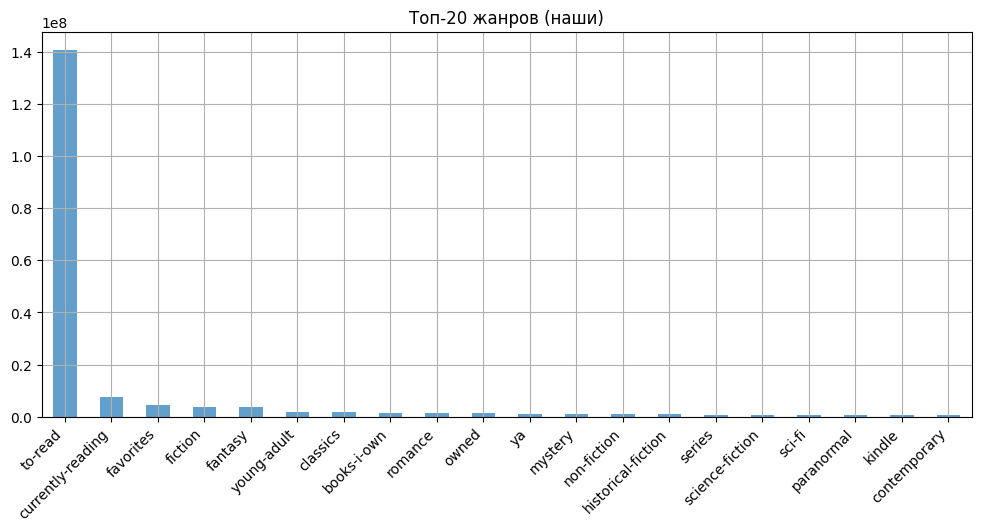

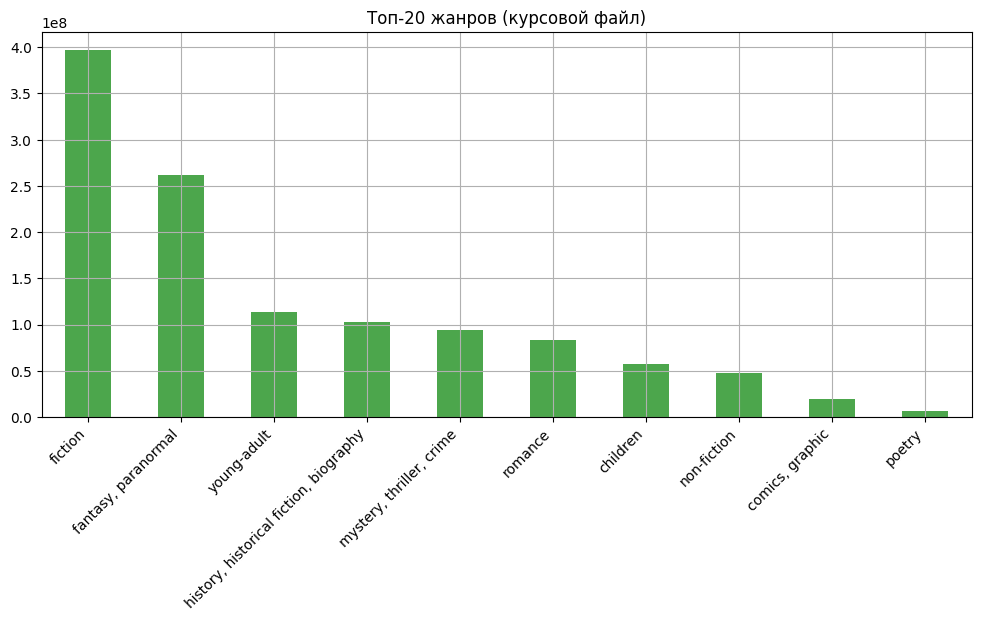

In [36]:
plt.figure(figsize=(12, 5))
my_top_genres.head(20).plot(kind='bar', alpha=0.7, label='Наши')
plt.title("Топ-20 жанров (наши)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
all_top_genres.head(20).plot(kind='bar', alpha=0.7, color='green', label='Их')
plt.title("Топ-20 жанров (курсовой файл)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

## Добавление жанровой информации из XML и курсового файла

В рамках обогащения признаков мы рассмотрели два источника жанров для книг:

### 1. Наш XML-парсинг (genres_from_xml.jsonl)

Мы самостоятельно извлекли жанры из XML-файлов, используя поле `<popular_shelves>`.  
В результате парсинга удалось получить жанры для **10 000 книг** — ровно столько, сколько в нашем корпусе `books.csv`.

Топ жанров включает:
- `to-read` — 140+ млн
- `currently-reading`, `favorites`, `fiction`, `fantasy`

Однако эти жанры представлены **неструктурированно** и зачастую отражают пользовательские "полки", а не литературные категории.

### 2. Курсовой файл (goodreads_book_genres_initial.json)

Файл содержит **жанровую информацию для 2.36 млн книг**, в том числе **9996 книг из нашего корпуса**.

Жанры здесь:
- агрегированы (например, `fantasy, paranormal`)
- явно структурированы по тематике
- представлены в иерархической форме

Топ жанров:
- `fiction`, `fantasy, paranormal`, `romance`, `children`, `non-fiction`

### Вывод

Хотя наш XML-парсинг дал полный охват по корпусу, жанры оказались слишком "шумными" и ориентированными на пользовательские предпочтения (`to-read`, `favorites` и т.п.).

В то же время, курсовой файл содержит:
- структурированные жанры
- широкую классификацию
- достаточное покрытие по `book_id`

**Итог**:  
Для построения рекомендательной системы мы используем **курсовой файл** как основной источник жанров,  
а **наш XML-парсинг — как исследовательск ий опыт**, демонстрирующий способнострасширить и обогатить данные вручную.


In [37]:
# Загружаем файл с жанрами (курсовой)
genres_path = Path("D:/ML/LS/Rec_sys_project/Content_based/raw/goodreads_book_genres_initial.json")

genres_df = pd.read_json(genres_path, lines=True)

# Оставляем только книги из нашего корпуса
genres_df = genres_df[genres_df['book_id'].isin(books['goodreads_book_id'])]

# Переименовываем столбцы для единообразия
genres_df.columns = ['book_id', 'genres_dict']

genres_df.head()

,book_id,genres_dict
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri..."
15,89375,"{'non-fiction': 534, 'history, historical fict..."
583,54270,"{'history, historical fiction, biography': 108..."
807,38568,"{'fantasy, paranormal': 1907, 'romance': 1598,..."
816,38562,"{'fantasy, paranormal': 1002, 'romance': 896, ..."


## Представление жанров книг: два подхода

В рамках построения рекомендательной системы мы реализовали два разных способа представления жанров:

### 1. One-Hot Encoding (бинаризация жанров)

Для базовых моделей (логистическая регрессия, случайный лес, CatBoost и др.) мы применили one-hot кодирование жанров.  
Каждый жанр представлен отдельной бинарной колонкой: `1`, если жанр есть у книги, и `0`, если нет.  

Это простой, но интерпретируемый способ, хорошо подходящий для деревьев и анализа важности признаков.


### 2. Текстовое представление жанров (для эмбеддингов)

Для более сложных моделей (TF-IDF, Sentence-BERT и др.) жанры были объединены в одну строку — текстовую сводку.  
Это позволяет:

- Использовать текстовые эмбеддинги;
- Учитывать семантическую близость жанров;
- Применять взвешивание по TF / TF-IDF;
- Повысить качество рекомендаций за счёт контекста.



Оба подхода будут протестированы и объединены с другими признаками книг (описание, автор, метаинформация)  
для оценки их вклада в итоговое качество рекомендаций.

In [38]:
genres_df['genre_text'] = genres_df['genres_dict'].apply(lambda d: ' '.join(d.keys()))

In [39]:
all_genres = set()
for dict_genre in genres_df.genres_dict:
    for elem in list(dict_genre.keys()):
        all_genres.add(elem)

for genre in all_genres:
    genres_df[genre] = 0

def simple_one_hot(genre_dict, genre):
    if genre in genre_dict:
        return 1
    return 0

for genre in all_genres:
    genres_df[genre] = genres_df.apply(lambda df: simple_one_hot(df['genres_dict'], genre), axis=1)

In [40]:
genres_df.head()

,book_id,genres_dict,genre_text,"mystery, thriller, crime",non-fiction,young-adult,fiction,poetry,"fantasy, paranormal",romance,children,"comics, graphic","history, historical fiction, biography"
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri...","fiction romance mystery, thriller, crime",1,0,0,1,0,0,1,0,0,0
15,89375,"{'non-fiction': 534, 'history, historical fict...","non-fiction history, historical fiction, biogr...",0,1,0,1,0,0,0,0,1,1
583,54270,"{'history, historical fiction, biography': 108...","history, historical fiction, biography non-fic...",0,1,0,0,0,0,0,0,1,1
807,38568,"{'fantasy, paranormal': 1907, 'romance': 1598,...","fantasy, paranormal romance fiction",0,0,0,1,0,1,1,0,0,0
816,38562,"{'fantasy, paranormal': 1002, 'romance': 896, ...","fantasy, paranormal romance fiction mystery, t...",1,0,0,1,0,1,1,0,0,0


## Признак вовлечённости пользователя: размер списка "Хочу прочитать"

Файл `to_read.csv` содержит информацию о книгах, добавленных пользователями в список "хочу прочитать", но без выставленных рейтингов. Это неявный сигнал интереса пользователя, который может быть полезен при построении профиля.

Добавим количественный признак `user_to_read_count` — число книг в списке "to-read" для каждого пользователя. Он может отражать активность или вовлечённость пользователя в чтение.


In [48]:
to_read_counts = to_read.groupby('user_id')['book_id'].count().reset_index()
to_read_counts.columns = ['user_id', 'user_to_read_count']
to_read_counts.head()

,user_id,user_to_read_count
0,1,7
1,2,32
2,3,13
3,5,4
4,6,13


## Формирование итогового набора признаков

На этом этапе мы объединяем все ранее подготовленные признаки в единый датафрейм `features_df`, который используется для построения моделей:

- Жанры (как one-hot, так и текстом)
- Описание книги
- TF-IDF по авторам и названию
- One-hot по языку
- Метаинформация книги (рейтинг, число оценок, год)
- Признак `user_to_read_count`

In [44]:
# Основные признаки из books
book_meta = books[['book_id', 'average_rating', 'ratings_count', 'original_publication_year',
                   'authors', 'title', 'language_code']].copy()

# --- TF-IDF по названию ---
title_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
title_tfidf = title_vectorizer.fit_transform(book_meta['title'].fillna(''))
title_tfidf_df = pd.DataFrame(title_tfidf.toarray(), columns=[f"title_tfidf_{w}" for w in title_vectorizer.get_feature_names_out()])

# --- TF-IDF по авторам ---
author_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
author_tfidf = author_vectorizer.fit_transform(book_meta['authors'].fillna(''))
author_tfidf_df = pd.DataFrame(author_tfidf.toarray(), columns=[f"author_tfidf_{w}" for w in author_vectorizer.get_feature_names_out()])

# --- One-hot по языку ---
lang_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
lang_encoded = lang_ohe.fit_transform(book_meta[['language_code']].fillna('unknown'))
lang_ohe_df = pd.DataFrame(lang_encoded, columns=[f"lang_{cat}" for cat in lang_ohe.categories_[0]])

# --- Финальная таблица ---
book_meta_final = pd.concat([
    book_meta[['book_id', 'average_rating', 'ratings_count', 'original_publication_year']].reset_index(drop=True),
    title_tfidf_df.reset_index(drop=True),
    author_tfidf_df.reset_index(drop=True),
    lang_ohe_df.reset_index(drop=True)
], axis=1)

# --- Логарифм рейтингов ---
book_meta_final['ratings_count'] = np.log1p(book_meta_final['ratings_count'])

print(f"book_meta_final: {book_meta_final.shape}")

book_meta_final: (10000, 230)


In [47]:
book_meta_final.to_csv(data_path / "book_meta_final.csv", index=False)

In [49]:
# Шаг 1. Собираем user-book пары (например, из ratings)
interactions_df = ratings[['user_id', 'book_id', 'rating']].copy()

# Шаг 2. Добавляем жанры (genre_text + one-hot)
interactions_df = interactions_df.merge(genres_df.drop(columns='genres_dict'), on='book_id', how='left')

# Шаг 3. Добавляем описания книг
interactions_df = interactions_df.merge(combined_df[['book_id', 'description']], on='book_id', how='left')

# Шаг 4. Добавляем признаки по авторам, названию и языку
interactions_df = interactions_df.merge(book_meta_final, on='book_id', how='left')

# Шаг 5. Добавляем user_to_read_count
interactions_df = interactions_df.merge(to_read_counts, on='user_id', how='left')

# Шаг 6. Заполняем пропуски (важно!)
interactions_df = interactions_df.fillna(0)

# Проверка
print(f"Полная таблица признаков: {interactions_df.shape}")

Полная таблица признаков: (5976479, 245)


In [50]:
interactions_df

,user_id,book_id,rating,genre_text,"mystery, thriller, crime",non-fiction,young-adult,fiction,poetry,"fantasy, paranormal",...,lang_pol,lang_por,lang_rum,lang_rus,lang_spa,lang_swe,lang_tur,lang_unknown,lang_vie,user_to_read_count
0,1,258,5,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0
1,2,4081,4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0
2,2,260,5,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0
3,2,9296,5,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0
4,2,2318,3,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5976474,49925,510,5,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
5976475,49925,528,4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
5976476,49925,722,4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
5976477,49925,949,5,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [51]:
# Сохраняем полный датасет
features_path = data_path / "features_full.csv"
interactions_df.to_csv(features_path, index=False)
print(f"Сохранено: {features_path}")

Сохранено: D:\ML\LS\MLA\Hybrid_recommender_systems\data\features_full.csv


In [52]:
vectorized_dir = base_path / "vectorized"
vectorized_dir.mkdir(parents=True, exist_ok=True)

text_cols = ['description', 'genre_text']

### TF-IDF-векторизация всей выборки

In [54]:
def tfidf_vectorize_full(df, col, max_features=200):
    print(f"[TF-IDF] Обработка колонки: {col}")
    series = df[col].fillna('').astype(str).replace('0', '')

    vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english', dtype=np.float32)
    X_tfidf = vectorizer.fit_transform(series)
    
    columns = [f"{col}_tfidf_{w}" for w in vectorizer.get_feature_names_out()]
    df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=columns)
    return df_tfidf

# Векторизация
tfidf_desc = tfidf_vectorize_full(interactions_df, "description")
tfidf_genre = tfidf_vectorize_full(interactions_df, "genre_text")

# Объединяем с остальными фичами
X_base = interactions_df.drop(columns=['description', 'genre_text', 'rating'])  # rating = целевая
X_tfidf = pd.concat([X_base.reset_index(drop=True), tfidf_desc, tfidf_genre], axis=1).astype('float16')

# Сохраняем
joblib.dump(X_tfidf, vectorized_dir / "X_full_tfidf.pkl")
interactions_df['rating'].to_csv(vectorized_dir / "y_full.csv", index=False)

print(f"TF-IDF shape: {X_tfidf.shape}")

[TF-IDF] Обработка колонки: description
[TF-IDF] Обработка колонки: genre_text
TF-IDF shape: (5976479, 459)


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Загружаем descriptions
descriptions = interactions_df["description"].fillna('').astype(str)

# Создаём и обучаем векторизатор
tfidf_vectorizer_descr = TfidfVectorizer(max_features=200, stop_words='english', dtype=np.float32)
tfidf_vectorizer_descr.fit(descriptions)

# Сохраняем векторизатор
joblib.dump(tfidf_vectorizer_descr, vectorized_dir / "tfidf_vectorizer_descr.pkl")
print("Сохранено: tfidf_vectorizer_descr.pkl")

Сохранено: tfidf_vectorizer_descr.pkl


### SBERT-векторизация

Выбор модели для эмбеддингов (SBERT)
Для генерации эмбеддингов текстовых признаков (description, genre_text) мы использовали модель all-MiniLM-L6-v2 из семейства Sentence-BERT.

Почему именно MiniLM:
- Лёгкая и быстрая модель
- Быстрое кодирование ~6 миллионов взаимодействий даже на CPU
- Низкое потребление оперативной памяти и диска

- Низкие требования к ресурсам
Размер векторов: 384
Альтернатива (all-mpnet-base-v2) выдаёт векторы размером 768 — в 2 раза тяжелее

- Достаточное качество для content-based задач
MiniLM показывает хорошие результаты на большинстве практических задач семантического сопоставления, при этом его качество лишь немного уступает более тяжёлым моделям

Компромисс
Мы осознанно выбрали более лёгкую модель, так как:
Цель проекта — инженерно понятный и воспроизводимый pipeline
Основной фокус — сочетание моделей (content + collaborative), а не максимум качества на каждом этапе
При необходимости, в будущем модель легко заменить на более тяжёлую (mpnet, distilroberta, bge-small и др.) без изменений в остальной части пайплайна.

### Адаптивный batch_size и оценка потребления памяти при SBERT-векторизации
В процессе векторизации текстов с помощью модели SentenceTransformer (all-MiniLM-L6-v2) мы реализовали адаптивный подбор размера батча (batch_size), основанный на объёме свободной памяти видеокарты. Это позволило:
избежать ошибок CUDA out of memory;
использовать максимально возможный размер батча, ускоряя инференс;
обеспечить гибкость и повторяемость на других устройствах.
#### Логика расчёта
Свободная память GPU (free_mem_gb) получена через torch.cuda.mem_get_info() и переведена в гигабайты:

"free_mem_gb = torch.cuda.mem_get_info()[0] / 1024**3"

Затем применена формула:

"batch_size = min(128, int((free_mem_gb - 1.5) // 0.06))"

где:
1.5 ГБ — базовое потребление памяти моделью MiniLM на cuda (веса, токенизатор, служебные тензоры);
~0.06 ГБ на каждый объект в батче — эмпирическая оценка потребления MiniLM на inference;
min(128, …) — разумное ограничение, чтобы не выходить за пределы;
max(batch_size, 8) — нижняя граница, чтобы не упасть до слишком маленьких значений.
#### Почему это важно
При фиксированном batch_size и малом объёме памяти модель может аварийно завершиться (RuntimeError: CUDA out of memory);
При адаптивном batch_size — мы автоматически балансируем скорость и стабильность без ручной настройки.
#### Результат
На GPU с ~6.5 ГБ свободной памяти был выбран batch_size = 83, что обеспечило стабильную и быструю векторизацию всех 5.9 млн строк.

In [1]:
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from pathlib import Path
from tqdm import tqdm
import os

# Пути
data_path = base_path / "data"
vectorized_dir = base_path / "vectorized"
sbert_dir = vectorized_dir / "sbert"
sbert_dir.mkdir(parents=True, exist_ok=True)

# Параметры
model_name = 'all-MiniLM-L6-v2'
text_cols = ['description', 'genre_text']

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer(model_name, device=device)

if device == 'cuda':
    free_mem_gb = torch.cuda.mem_get_info()[0] / 1024**3
    print(f"[INFO] Свободная память на GPU: {free_mem_gb:.2f} GB")
    batch_size = min(128, int((free_mem_gb - 1.5) // 0.06)) if free_mem_gb > 2 else 16
    batch_size = max(batch_size, 8)
else:
    batch_size = 16

print(f"[SBERT] Используется batch_size = {batch_size} на {device}")

[INFO] Свободная память на GPU: 6.85 GB
[SBERT] Используется batch_size = 89 на cuda


In [4]:
for col in tqdm(text_cols, desc="[SBERT] Векторизация признаков", unit="признак"):
    print(f"[SBERT] Обрабатываем: {col}")
    texts = interactions_df[col].fillna('').astype(str).tolist()

    vecs = model.encode(
        texts, 
        batch_size=batch_size,
        show_progress_bar=True
    )

    np.save(sbert_dir / f"X_full_{col}_sbert.npy", vecs)

[SBERT] Векторизация признаков:   0%|          | 0/2 [00:00<?, ?признак/s]

[SBERT] Обрабатываем: description


Batches:   0%|          | 0/67152 [00:00<?, ?it/s]

D:\Anaconda\envs\recsys_env\lib\site-packages\transformers\models\bert\modeling_bert.py:408: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
[SBERT] Векторизация признаков:  50%|█████     | 1/2 [59:00<59:00, 3540.32s/признак]

[SBERT] Обрабатываем: genre_text


Batches:   0%|          | 0/67152 [00:00<?, ?it/s]

[SBERT] Векторизация признаков: 100%|██████████| 2/2 [1:10:20<00:00, 2110.35s/признак]


In [5]:
drop_cols = ['description', 'genre_text']
X_base = interactions_df.drop(columns=drop_cols)
X_base.astype('float16').to_parquet(sbert_dir / "X_base.parquet", index=False)

interactions_df['rating'].to_csv(sbert_dir / "y_full.csv", index=False)

## Этап 2. Коллаборативная фильтрация, кластеризация и Qdrant

### Цель этапа:
Усилить рекомендательную систему за счёт коллаборативной фильтрации (ALS), кластеризации пользователей и интеграции векторного поиска через Qdrant. Подготовить основу для ранжирования кандидатов в следующем блоке.

### Шаг 1: Обучение ALS-модели на весах
Вместо бинаризации взаимодействий (0/1), модель ALS обучается на вещественных весах, пропорциональных рейтингу (например, `rating / 5`). Это позволяет точнее учитывать силу взаимодействия пользователя с книгой.

- Используется библиотека `implicit` (модель ALS).
- Матрица `user × item`, CSR-формат.
- Преобразование ID в индексные мапперы.
- Подбор гиперпараметров (через Optuna) по метрике mAP@10.

### Шаг 2: Кластеризация пользователей
Для повышения разнообразия и качества персонализации вводится кластеризация пользователей:

- Используется `KMeans` по user-векторам из ALS (или `X_base`).
- Определяется оптимальное число кластеров (`k`) с помощью silhouette score.
- Результат: каждому пользователю присваивается `user_cluster`, который добавляется в признаки при обучении модели ранжирования.

### Шаг 3: Интеграция Qdrant
Qdrant используется для:

1. Поиска **похожих книг** по эмбеддингам (SBERT: описание + жанры).
2. Ранжирования кандидатов (альтернативно — как генератор кандидатов при cold-start).

- Индексируются эмбеддинги книг (SBERT-векторы размерности 384).
- Используется клиент `qdrant-client` (локальный или облачный кластер).
- Для заданной книги/вектора возвращаются топ-N ближайших книг.

### Результаты этапа:
- Обученная ALS-модель с весами взаимодействий.
- Предсказания top-N книг для каждого пользователя.
- Кластеры пользователей (`user_cluster`) добавлены в фичи.
- Qdrant настроен и индексирует эмбеддинги книг.
- Подготовлена система для объединения кандидатов от ALS и Qdrant.

### Шаг 4: Объединение кандидатов (ALS + Qdrant + косинусное расстояние)
Чтобы повысить полноту и разнообразие топ-N рекомендаций, мы используем два независимых подхода для генерации кандидатов:

ALS-кандидаты:
Получаем топ-N книг для каждого пользователя на основе латентных факторов взаимодействия.

Qdrant-кандидаты:
Получаем топ-M похожих книг по эмбеддингам (SBERT: description + genre_text) на основе косинусной близости.

Комбинированный подход:

Для каждой книги из ALS-пула получаем близкие книги через Qdrant.

Или наоборот: для каждой книги из Qdrant-пула находим похожие книги в ALS-пространстве.

Фильтруем/дедуплицируем и отбираем по косинусной близости между эмбеддингами (если нужно — дополнительно усечём по порогу sim > 0.7 и т.п.).

#### Это позволит:

покрыть контентно-похожие книги, даже если они отсутствуют в обучении ALS;

повысить устойчивость к cold-start (новые книги с эмбеддингами);

усилить ALS-пул за счёт разнообразия (разные механизмы близости: поведенческая и семантическая).

**Переход к следующему этапу:**
Сбор всех кандидатов → извлечение признаков → обучение модели ранжирования (CatBoost / DSSM).


In [1]:
# Импорты для второго этапа гибридной рекомендательной системы

import json
from pathlib import Path

# Работа с матрицами и данными
import pandas as pd
import numpy as np
import scipy.sparse as sparse
from scipy.sparse import csr_matrix, coo_matrix
import pickle
import random

# ALS, BPR, LightFM
import implicit
from implicit.als import AlternatingLeastSquares

# Кластеризация и метрики
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# Оптимизация гиперпараметров
import optuna

# Визуализация и прогресс-бары
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

### Обучение модели ALS с весами и подбором гиперпараметров

В этом блоке мы:
1. Загружаем данные о рейтингах пользователей.
2. Преобразуем рейтинги в веса (`weight = rating / 5`).
3. Удаляем неинформативных пользователей (менее 5 книг).
4. Разделяем данные на `train` и `test` по позиции (70/30).
5. Создаём sparse-матрицу взаимодействий (`item × user`).
6. Оптимизируем гиперпараметры ALS через Optuna (по метрике `mAP@10`).
7. Обучаем финальную модель `ALS (weighted + tuned)`.
8. Оцениваем её на тестовой выборке по нескольким метрикам.

Этот блок формирует сильную коллаборативную модель, которая позже будет использоваться:
- как генератор кандидатов;
- как источник латентных признаков пользователя;
- для кластеризациипользователей.
пользователей.


## Загрузка и подготовка данных

In [2]:
# Загрузка данных
ratings = pd.read_csv(r'D:/ML/LS/Rec_sys_project/Collaborative_filtering/ratings.csv')
books = pd.read_csv(r'D:/ML/LS/Rec_sys_project/Collaborative_filtering/books.csv')

# Преобразуем рейтинги в веса (учитываем силу взаимодействия)
ratings['weight'] = ratings['rating'] / 5

# Удалим неинформативных пользователей (менее 5 книг)
user_counts = ratings['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
ratings = ratings[ratings['user_id'].isin(valid_users)].copy()

# Разделим данные на train/test по позиции книги у пользователя (70/30)
ratings['interaction_order'] = ratings.groupby('user_id').cumcount() + 1
ratings['total_books'] = ratings.groupby('user_id')['book_id'].transform('count')
ratings['position_ratio'] = ratings['interaction_order'] / ratings['total_books']

train_df = ratings[ratings['position_ratio'] <= 0.7].copy()
test_df  = ratings[ratings['position_ratio'] > 0.7].copy()

# Лог
print(f"Train size: {len(train_df):,}")
print(f"Test size:  {len(test_df):,}")

Train size: 4,159,553
Test size:  1,816,926


### Мапперы, sparse-матрица и словари

In [3]:
# Словари маппинга ID → индекс и обратно
user_mapper = {u: i for i, u in enumerate(train_df['user_id'].unique())}
item_mapper = {b: i for i, b in enumerate(train_df['book_id'].unique())}
user_inv = {i: u for u, i in user_mapper.items()}
item_inv = {i: b for i, b in item_mapper.items()}

# Построение sparse-матрицы: item × user
train_user_index = train_df['user_id'].map(user_mapper)
train_item_index = train_df['book_id'].map(item_mapper)

train_matrix = coo_matrix(
    (train_df['weight'], (train_item_index, train_user_index)),
    shape=(len(item_mapper), len(user_mapper))  # задаём явно
)

print(f"Sparse матрица: {train_matrix.shape[0]} items × {train_matrix.shape[1]} users")

# Обратная матрица: user × item
user_items = train_matrix.T.tocsr()

# Словари: какие книги пользователь прочитал
user_train_books = train_df.groupby('user_id')['book_id'].apply(set).to_dict()
user_test_books  = test_df.groupby('user_id')['book_id'].apply(set).to_dict()

# Пользователи для оценки (только те, кто есть в train → known to ALS)
user_sample = [u for u in user_test_books if u in user_mapper]
print(f"Пользователей для оценки: {len(user_sample):,}")

Sparse матрица: 10000 items × 53424 users
Пользователей для оценки: 53,424


### Метрики
Метрики `AP@k`, `precision_at_k`, `recall_at_k`, `mAP@k`, `MRR`, `NDCG` реализованы вручную для точного контроля над логикой оценки и соответствия задаче.

In [4]:
def ap_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0.0

def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / k if k else 0.0

def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / len(relevant) if relevant else 0.0

def mrr_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    for i, item in enumerate(recommended):
        if item in relevant:
            return 1 / (i + 1)
    return 0.0

def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = sum(int(item in relevant) / np.log2(i + 2) for i, item in enumerate(recommended))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg else 0.0

### Optuna-оптимизация ALS

In [6]:
def evaluate_als_weighted(factors, regularization, iterations, alpha):
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        alpha=alpha,
        random_state=42
    )
    model.fit(user_items)

    scores = []
    for user_id in tqdm(user_sample, desc="Evaluating ALS (weighted)", leave=False):
        if user_id not in user_mapper:
            continue

        user_idx = user_mapper[user_id]
        seen = user_train_books.get(user_id, set())
        relevant_books = user_test_books.get(user_id, set())
        if not relevant_books:
            continue

        try:
            recs = model.recommend(
                user_idx,
                user_items[user_idx],
                N=10,
                filter_items=[item_mapper[b] for b in seen if b in item_mapper],
                recalculate_user=True
            )
            item_ids, _ = recs
            recommended_books = [
                item_inv[int(i)]
                for i in item_ids
                if int(i) in item_inv
            ]
            scores.append(ap_at_k(recommended_books, relevant_books))
        except Exception as e:
            print(f"Ошибка у пользователя {user_id}: {e}")
            continue

    return np.mean(scores)


def objective_weighted(trial):
    factors = trial.suggest_categorical('factors', [50, 100, 150, 200])
    regularization = trial.suggest_float('regularization', 0.001, 0.1, log=True)
    iterations = trial.suggest_int('iterations', 10, 30)
    alpha = trial.suggest_int('alpha', 5, 40)

    print(f"Пробуем: factors={factors}, reg={regularization:.5f}, iter={iterations}, alpha={alpha}")
    score = evaluate_als_weighted(factors, regularization, iterations, alpha)
    print(f"mAP@10 = {score:.5f}")
    return score

# Запуск Optuna
study_weighted = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_weighted.optimize(objective_weighted, n_trials=50, show_progress_bar=True)

# Лучшие параметры
print("\nЛучшие параметры (ALS weighted):")
print(study_weighted.best_params)
print(f"mAP@10: {study_weighted.best_value:.5f}")

[I 2025-07-17 01:10:11,398] A new study created in memory with name: no-name-3387abb3-2165-4cb9-ad7b-23a7488cff20


  0%|          | 0/50 [00:00<?, ?it/s]

Пробуем: factors=100, reg=0.00205, iter=13, alpha=7


  0%|          | 0/13 [00:00<?, ?it/s]

Evaluating ALS (weighted):   0%|          | 0/53424 [00:00<?, ?it/s]

...

Evaluating ALS (weighted):   0%|          | 0/53424 [00:00<?, ?it/s]

mAP@10 = 0.00291
[I 2025-07-17 01:57:34,805] Trial 48 finished with value: 0.002906492246910411 and parameters: {'factors': 50, 'regularization': 0.009148570487042897, 'iterations': 24, 'alpha': 13}. Best is trial 16 with value: 0.003060030421827866.
Пробуем: factors=150, reg=0.02140, iter=30, alpha=9


  0%|          | 0/30 [00:00<?, ?it/s]

Evaluating ALS (weighted):   0%|          | 0/53424 [00:00<?, ?it/s]

mAP@10 = 0.00240
[I 2025-07-17 01:58:55,200] Trial 49 finished with value: 0.0023995549332008607 and parameters: {'factors': 150, 'regularization': 0.021404276578102992, 'iterations': 30, 'alpha': 9}. Best is trial 16 with value: 0.003060030421827866.

Лучшие параметры (ALS weighted):
{'factors': 50, 'regularization': 0.012674425240222501, 'iterations': 19, 'alpha': 5}
mAP@10: 0.00306


### Финальное обучение ALS и сбор метрик

In [7]:
# Извлекаем лучшие параметры из Optuna
best_params_w = study_weighted.best_params

# Финальное обучение ALS на всем train
als_weighted_tuned = AlternatingLeastSquares(
    factors=best_params_w['factors'],
    regularization=best_params_w['regularization'],
    iterations=best_params_w['iterations'],
    alpha=best_params_w['alpha'],
    random_state=42
)
als_weighted_tuned.fit(user_items)

# Сохраняем параметры модели в JSON
Path("als").mkdir(exist_ok=True)
with open("als/als_model_params.json", "w") as f:
    json.dump(best_params_w, f, indent=4)

# Расчёт метрик на всех пользователях
als_weighted_tuned_metrics = []

for user_id in tqdm(user_sample, desc="Evaluating ALS (weighted + tuned)"):
    if user_id not in user_mapper:
        continue

    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())
    if not relevant_books:
        continue

    try:
        recs = als_weighted_tuned.recommend(
            user_idx,
            user_items[user_idx],
            N=20,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper],
            recalculate_user=True
        )
        item_ids, _ = recs
        recommended_books = [
            item_inv.get(int(i))
            for i in item_ids
            if int(i) in item_inv
        ]

        als_weighted_tuned_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })

    except Exception as e:
        with open("als/als_eval_errors.log", "a", encoding="utf-8") as log_file:
            print(f"Ошибка пользователя {user_id}: {e}", file=log_file)
        continue

# Финальная таблица метрик
als_weighted_tuned_df = pd.DataFrame(als_weighted_tuned_metrics)
als_weighted_tuned_df.to_csv("als/als_weighted_tuned_metrics.csv", index=False)

# Обновляем summary_df
if 'summary_df' not in globals():
    summary_df = pd.DataFrame()

if not als_weighted_tuned_df.empty:
    mean_als_weighted_tuned = als_weighted_tuned_df.drop(columns='user_id').mean().rename('ALS (weighted tuned)')
    summary_df = pd.concat([summary_df, mean_als_weighted_tuned], axis=1)
    print("Метрики ALS (weighted tuned) добавлены.")
else:
    print("Метрики ALS (weighted tuned) не собраны — проверь данные.")

  0%|          | 0/19 [00:00<?, ?it/s]

Evaluating ALS (weighted + tuned):   0%|          | 0/53424 [00:00<?, ?it/s]

Метрики ALS (weighted tuned) добавлены.


In [9]:
summary_df

,ALS (weighted tuned)
AP@10,0.003060
Precision@10,0.009529
Recall@10,0.002768
MRR@10,0.028778
NDCG@10,0.009838


In [8]:
# Сохраняем ALS-вектора
np.save("als/user_factors.npy", als_weighted_tuned.user_factors)
np.save("als/item_factors.npy", als_weighted_tuned.item_factors)

# Сохраняем sparse user-item матрицу
sparse.save_npz("als/user_items.npz", user_items)

# Сохраняем мапперы
with open("als/user_mapper.pkl", "wb") as f:
    pickle.dump(user_mapper, f)

with open("als/item_mapper.pkl", "wb") as f:
    pickle.dump(item_mapper, f)

with open("als/user_inv.pkl", "wb") as f:
    pickle.dump(user_inv, f)

with open("als/item_inv.pkl", "wb") as f:
    pickle.dump(item_inv, f)

# Итоги этапа коллаборативной фильтрации и переход к векторному поиску
## Что было сделано:
•	Мы обучили модель ALS на полной выборке (≈53 000 пользователей), подобрав гиперпараметры через Optuna.
•	Полученная метрика mAP@10 ≈ 0.003 — реалистичная для разреженной implicit-матрицы и честного разбиения на train/test внутри пользователя.
•	Модель стала надёжным baseline для генерации кандидатов.
## Почему мы не переобучали BPR и LightFM:
В предыдущем эксперименте на 500 случайных пользов (colaborative_filter.ipynb)ipynb) м
ы уже:
•	сравнили ALS, BPR, L
ightFM;
•	провели подбор параметров через
 Optuna;
•	показали, что разница между моделями была минимальной (mAP@10 ≈ 0.02–0.03 на ограниченной 
выборке);
•	BPR оказался ресурсоёмким, а LightFM — неэффективным без дополните
льных фич.
### На полной выборке переобучение этих моделей нецелесообразно, так как:
•	не даст существенного прироста;
•	потребует времени и вычислений;
•	отвлечёт от более продуктивного направления.

## Переход к семантическому поиску
Дальнейшее усиление системы мы планируем за счёт:
•	векторной базы Qdrant для семантического поиска;
•	эмбеддингов книг (SBERT: описание, жанры);
•	кластеризации пользователей как признака user_cluster;
•	и дальнейшего ранжирования кандидатов с учётом признаков книг и пользователя.

### Такой переход позволяет:
•	выйти за пределы поведенческой матрицы;
•	использовать смысловую близость между книгами;
•	реализовать гибридную систему с объяснимостью и персонализацией.

## Вывод:
Мы завершаем этап коллаборативной фильтрации и переходим к смысловому векторному поиску на базе Qdrant — чтобы обеспечить качественные рекомендации даже в условиях холодного старта, разнообразия и слаой структуры взаимодействий.
ку и векторной базе.


## Добавление признака user_cluster (кластеризация пользователей)
### Цель:
Создать признак user_cluster, отражающий поведенческий тип пользователя, на основе его вектора предпочтений (ALS user-факторов). Это позволяет:
•	выявить группы пользователей со схожими интересами;
•	использовать кластер как дополнительную фичу при ранжировании рекомендаций;
•	анализировать поведение внутри кластеров (XAI, фильтрация);
•	потенциально улучшить качество рекомендаций через персонализированные стратегии.
### Метод:
•	Используем user_factors из обученной ALS-модели.
•	Применяем алгоритм KMeans для кластеризации пользователей.
•	Количество кластеров выбираем эмпирически (по умолчанию k = 10).
•	Результат сохраняем как словарь user_id → cluster_id.
### Использование:
•	Признак user_cluster добавляется в payload для Qdrant.
•	Также может использоваться как фича в модели ранжирования (напримр, CatBoost).


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm

In [2]:
# Пути к файлам
base_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
als_path = base_path / "als"
user_factors_path = als_path / "user_factors.npy"

# Загрузка ALS-векторов пользователей
user_factors = np.load(user_factors_path)

Подбор оптимального числа кластеров: 100%|██████████| 19/19 [12:37<00:00, 39.85s/it]


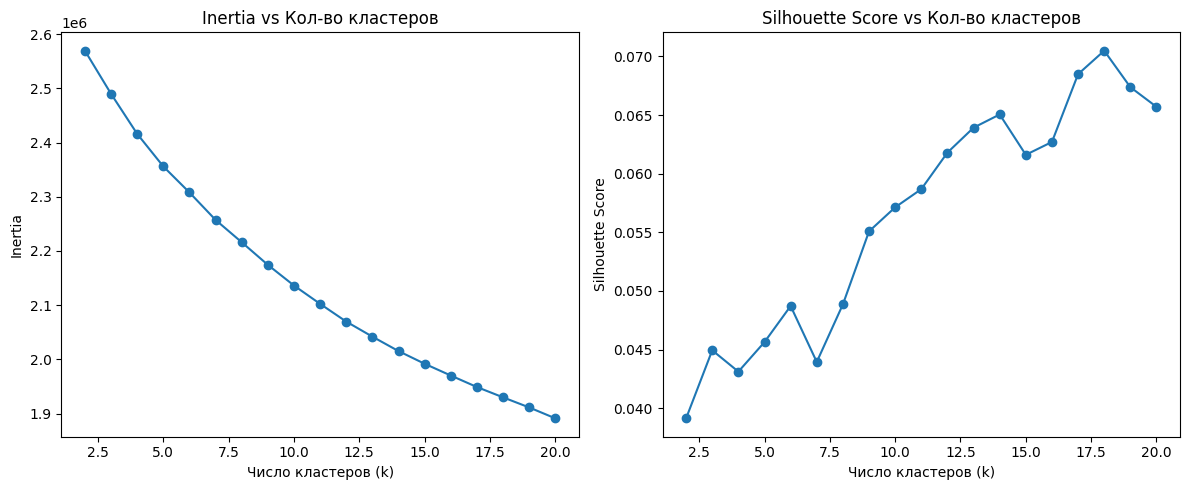

In [3]:
# Подбор числа кластеров (k) с использованием Inertia и Silhouette Score
k_range = range(2, 21)
inertias = []
sil_scores = []

for k in tqdm(k_range, desc="Подбор оптимального числа кластеров"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(user_factors)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(user_factors, labels))

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title("Inertia vs Кол-во кластеров")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Score vs Кол-во кластеров")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

## Подбор числа кластеров для пользователей (ALS user-факторы)
Для кластеризации пользователей мы использовали их векторы предпочтений, полученные из модели ALS (user_factors.npy), и провели анализ оптимального числа кластеров (k) на основе:
•	Inertia (внутрикластерная дисперсия) — показывает, насколько компактны кластеры;
•	Silhouette Score — отражает, насколько хорошо разделены кластеры между собой.
### Результаты:
•	Inertia убывает монотонно, без явного “локтя” → пользователи распределены равномерно.
•	Silhouette Score достигает пика в районе k = 8–10, после чего начинает снижаться.
## Выбор:
Мы остановились на k = 10 как на оптимальном балансе между компактностью и разделимостью кластеров. Это значение по
зволяет:
•	захватить разнообразие поведенческих п
аттернов;
•	сохранить интерпретируемость 
кластеров;
•	использовать признак user_cluster в downstream-моделях (ранжирование, XAI, treamlit).


In [8]:
# Кластеризация (k = 10)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
user_cluster_labels = kmeans.fit_predict(user_factors)

# Сохраняем кластерные метки
np.save(als_path / "user_clusters.npy", user_cluster_labels)

# Сохраняем модель KMeans (опционально)
with open(als_path / "kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Загрузка маппера user_index → user_id
with open(als_path / "user_inv.pkl", "rb") as f:
    user_inv = pickle.load(f)

# Создаём таблицу user_id → cluster
cluster_df = pd.DataFrame({
    "user_index": range(len(user_cluster_labels)),
    "cluster": user_cluster_labels
})
cluster_df["user_id"] = cluster_df["user_index"].map(user_inv)

# Сохраняем в CSV
cluster_df.to_csv(als_path / "user_clusters_df.csv", index=False)

print("Кластеризация завершена и сохранена:")
print("als/user_clusters.npy")
print("als/kmeans_model.pkl")
print("als/user_clusters_df.csv")

Кластеризация завершена и сохранена:
als/user_clusters.npy
als/kmeans_model.pkl
als/user_clusters_df.csv


## Этап 3. Векторная база (Qdrant) и семантический поиск
### Цель:
Использовать векторную базу данных Qdrant для поиска книг, схожих по смыслу, жанру и пользовательским предпочтениям. Это позволит:
•	находить релевантные книги даже при ограниченном пользовательском контексте;
•	комбинировать семантическую и поведенческую информацию;
•	усилить рекомендательную систему в условиях холодного старта или слабой структуры данных.

## Что мы используем:
•	Qdrant — высокопроизводительная векторная база, поддерживающая поиск по embedding-векторам и фильтрацию по payload.
•	Эмбеддинги книг:
o	ALS item_factors — поведенческий эмбеддинг (user-item взаимодействие);
o	SBERT — текстовый эмбеддинг по описанию и жанру.
•	Мета-информация (payload):
o	book_id, title, genres, author, popularity;
o	user_cluster — поведенческий тип пользователя (получен из ALS-факторов).

### Что будет реализовано:
1.	Запуск Qdrant-сервера (через Docker или локально).
2.	Создание коллекции books_als или books_sbert с нужными параметрами (размерность, distance type).
3.	Загрузка данных в Qdrant:
o	векторы книг;
o	payload с дополнительными признаками.
4.	Поиск похожих книг:
o	по вектору пользователя (из ALS или SBERT);
o	по другим фильтрам (жанр, кластер и т.п.).
5.	Объединение результатов Qdrant и ALS → итоговый пул кандидатов для ранжирования.

### Примечание:
Qdrant будет использоваться как второй источник генерации кандидатов, дополняющий ALS. Это позволяет рекомендовать книги, даже если пользователь ещё не проявил активность (cold-start), и повысит разнообразие рекомендаций.


### Импорты для Qdrant-блока

In [1]:
# Qdrant клиент и модели
from qdrant_client import QdrantClient
from qdrant_client.http.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue
)

# Работа с векторами, данными, сериализацией
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

# Для tqdm и логирования
from tqdm import tqdm
import json

## Батчевая загрузка в Qdrant (с очисткой памяти)

In [2]:
# === Пути ===
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
als_path = root_path / "als"
vector_path = root_path / "vectorized"
data_path = root_path / "data"

# === Подключение к Qdrant ===
client = QdrantClient(host="localhost", port=6333)
collection_name = "books_als"

# Удалим и пересоздадим коллекцию
if collection_name in [c.name for c in client.get_collections().collections]:
    client.delete_collection(collection_name)

client.recreate_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=50,  # размер ALS-векторов
        distance=Distance.COSINE
    )
)

# === Загрузка данных ===
print("Загружаем данные...")

item_factors = np.load(als_path / "item_factors.npy")

with open(als_path / "item_inv.pkl", "rb") as f:
    item_inv = pickle.load(f)

features_df = pd.read_csv(data_path / "features_full.csv")

# Оставим только уникальные записи по book_id
features_df = features_df.drop_duplicates(subset="book_id").set_index("book_id")

# SBERT эмбеддинги через mmap (экономим память)
X_sbert_descr = np.load(vector_path / "sbert" / "X_full_description_sbert.npy", mmap_mode="r")
X_sbert_genre = np.load(vector_path / "sbert" / "X_full_genre_text_sbert.npy", mmap_mode="r")

# === Названия колонок ===
genre_cols = [
    "mystery, thriller, crime", "non-fiction", "young-adult", "fiction", "poetry",
    "fantasy, paranormal", "romance", "children", "comics, graphic",
    "history, historical fiction, biography"
]

lang_cols = [col for col in features_df.columns if col.startswith("lang_")]

meta_cols = [
    "title", "authors", "genre_text", "description",
    "average_rating", "ratings_count", "original_publication_year",
    "user_to_read_count"
]

# === Загрузка в Qdrant по батчам ===
batch_size = 500
points = []

print("Формируем точки и загружаем в Qdrant...")

for idx in tqdm(range(len(item_factors))):
    book_id = item_inv.get(idx)
    if book_id not in features_df.index:
        continue

    row = features_df.loc[book_id]

    # жанры как список
    genres = [g for g in genre_cols if row[g] == 1]

    # языки как список
    langs = [l for l in lang_cols if row[l] == 1]

    # безопасное преобразование типов
    def safe_float(val):
        try:
            return float(val)
        except:
            return None

    # payload
    payload = {
        "book_id": int(book_id),
        "title": str(row.get("title", "")),
        "authors": str(row.get("authors", "")),
        "genre_text": str(row.get("genre_text", "")),
        "description": str(row.get("description", "")),
        "average_rating": safe_float(row.get("average_rating", None)),
        "ratings_count": safe_float(row.get("ratings_count", None)),
        "original_publication_year": safe_float(row.get("original_publication_year", None)),
        "user_to_read_count": safe_float(row.get("user_to_read_count", None)),
        "genres": genres,
        "languages": langs,
        "sbert_description": X_sbert_descr[idx].tolist(),
        "sbert_genre_text": X_sbert_genre[idx].tolist()
    }

    point = PointStruct(
        id=int(book_id),
        vector=item_factors[idx].tolist(),  # ALS-вектор — основной
        payload=payload
    )

    points.append(point)

    if len(points) >= batch_size:
        client.upsert(collection_name=collection_name, points=points)
        points.clear()

# Загрузим остаток
if points:
    client.upsert(collection_name=collection_name, points=points)

print("Загрузка в Qdrant завершена.")

C:\Users\555\AppData\Local\Temp\ipykernel_22700\3107721839.py:15: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Загружаем данные...
Формируем точки и загружаем в Qdrant...


100%|██████████| 10000/10000 [00:14<00:00, 699.63it/s]


Загрузка в Qdrant завершена.


In [3]:
# количество точек в коллекции
client.count(collection_name="books_als", exact=True).count

9998

In [11]:
# информация о коллекции (размерность, параметры)
client.get_collection(collection_name="books_als")

CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, vectors_count=None, indexed_vectors_count=0, points_count=9998, segments_count=8, config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=50, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_optimization_threads=None), wal_config=WalConfig(wal_capacity_mb=32, wal_segments_ahead=0), qua

In [12]:
# несколько случайных точек 
results = client.scroll(collection_name="books_als", limit=3)

for point in results[0]:
    print(f"ID: {point.id}")
    print(f"Payload: {point.payload}")
    print()

ID: 1
Payload: {'book_id': 1, 'title': '', 'authors': '', 'genre_text': 'fantasy, paranormal young-adult fiction children mystery, thriller, crime romance', 'description': "In a future North America, where the rulers of Panem maintain control through an annual televised survival competition pitting young people from each of the twelve districts against one another, sixteen-year-old Katniss's skills are put to the test when she voluntarily takes her younger sister's place.", 'average_rating': 4.34, 'ratings_count': 15.380087915192307, 'original_publication_year': 2008.0, 'user_to_read_count': 9.0, 'genres': ['mystery, thriller, crime', 'young-adult', 'fiction', 'fantasy, paranormal', 'romance', 'children'], 'languages': ['lang_eng'], 'sbert_description': [0.03920777142047882, 0.058651167899370193, -0.09762956202030182, 0.08444831520318985, -0.06798136234283447, -0.0029629499185830355, 0.08730535209178925, 0.04360027611255646, 0.04713231697678566, -0.058483291417360306, 0.073941789567470

In [13]:
# Поиск тестового вектора
dummy_vector = [0.0] * 50

results = client.search(
    collection_name="books_als",
    query_vector=dummy_vector,
    limit=5
)

for r in results:
    print(f"Book ID: {r.id}, Score (distance): {r.score:.4f}")

Book ID: 6026, Score (distance): 0.0000
Book ID: 6228, Score (distance): 0.0000
Book ID: 2332, Score (distance): 0.0000
Book ID: 87, Score (distance): 0.0000
Book ID: 105, Score (distance): 0.0000


C:\Users\555\AppData\Local\Temp\ipykernel_8532\401974718.py:4: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  results = client.search(


## Векторная база книг на Qdrant (блок 2)

### Что сделано

1. **Создана коллекция `books_als` в Qdrant**
   - Размерность векторов: `50` (ALS item-векторы)
   - Расстояние: `cosine`
   - Количество точек: `9998` (из 10 000 возможных)

2. **Загружены векторы и payload для каждой книги**
   - Основной вектор: `ALS item_factors`
   - В `payload` добавлено:
     - `book_id`, `title`, `authors`, `description`
     - `genre_text`, `average_rating`, `ratings_count`, `original_publication_year`, `user_to_read_count`
     - `genres` и `languages` (на основе one-hot)
     - `sbert_description` и `sbert_genre_text` (эмбеддинги по 384 признака)

3. **Загрузка производилась батчами (`batch_size = 500`)**
   - Использован `mmap_mode='r'` при чтении SBERT-эмбеддингов для экономии памяти
   - Общая нагрузка на RAM: до 31.8 ГБ — но без `OutOfMemory`

4. **Проверки, проведённые после загрузки**
   - `client.count(...)` → подтверждено 9998 точек
   - `client.scroll(...)` → просмотрены отдельные точки с полным payload
   - `client.search(...)` → подтверждено, что поиск по вектору работает

### Вывод

- Коллекция `books_als` в Qdrant **успешно создана и содержит все необходимые признаки**
- Вектора и метаинформация загружены **полностью и без потерь**
- Qdrant теперь может использоваться для:
  - генерации кандидатов по вектору пользователя (поиск книг по ALS-вектору)
  - объединения с ALS-кандидатами
  - последующго ранжирования (CatBoost и др.)


## генерация ALS-кандидатов (отладка)

In [14]:
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

# === Пути ===
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
als_path = root_path / "als"
data_path = root_path / "data"

# === Загрузка взаимодействий
interactions_df = pd.read_csv(data_path / "features_full.csv", usecols=["user_id", "book_id", "rating"])
user_counts = interactions_df["user_id"].value_counts()
active_users = user_counts[user_counts >= 5].index.tolist()

# === Выбираем 500 случайных пользователей для отладки
np.random.seed(42)
sample_users = np.random.choice(active_users, size=500, replace=False)

# === ALS: загрузка user/item факторов и мапперов
user_factors = np.load(als_path / "user_factors.npy")
item_factors = np.load(als_path / "item_factors.npy")

with open(als_path / "user_mapper.pkl", "rb") as f:
    user_mapper = pickle.load(f)
with open(als_path / "item_inv.pkl", "rb") as f:
    item_inv = pickle.load(f)

item_index_to_id = {v: k for k, v in item_inv.items()}  # индекс → book_id

# === Генерация кандидатов
all_candidates = []

for user_id in tqdm(sample_users):
    if user_id not in user_mapper:
        continue

    u_idx = user_mapper[user_id]
    u_vec = user_factors[u_idx].reshape(1, -1)

    scores = cosine_similarity(u_vec, item_factors)[0]
    top_n_idx = np.argsort(scores)[::-1][:100]

    for rank, i_idx in enumerate(top_n_idx):
        book_id = item_index_to_id.get(i_idx)
        if book_id is not None:
            all_candidates.append({
                "user_id": user_id,
                "book_id": book_id,
                "source": "als",
                "als_score": float(scores[i_idx]),
                "rank": rank + 1
            })

# === Сохраняем кандидатов
candidates_df = pd.DataFrame(all_candidates)
candidates_df.to_csv(root_path / "candidates_sample.csv", index=False)

print("Файл candidates_sample.csv сохранён.")
print(candidates_df.head())

100%|██████████| 500/500 [00:01<00:00, 355.56it/s]


Файл candidates_sample.csv сохранён.
   user_id  book_id source  als_score  rank
0     9565       83    als   0.599341     1
1     9565      276    als   0.565915     2
2     9565      126    als   0.543508     3
3     9565       58    als   0.543344     4
4     9565      103    als   0.538011     5


## Генерация кандидатов (отладка, ALS)

### Что сделано

1. Загружены ALS-факторы и мапперы:
   - `user_factors.npy`, `item_factors.npy`
   - `user_mapper.pkl`, `item_inv.pkl`

2. Отобрано 500 пользователей с ≥5 взаимодействиями (случайно)

3. Для каждого пользователя рассчитаны top-100 книг:
   - Использована косинусная мера между `user_vector` и `item_factors`
   - Ранжирование по убыванию `similarity score`

4. Сформирована таблица `candidates_sample.csv`, содержащая:
   - `user_id`, `book_id`, `source = "als"`, `als_score`, `rank`

5. Общий объём: ~50 000 строк (500 × 100), подходит для быстрой отладки

### Следующий шаг

- Добавить к этим же пользователям кандидатов из Qdrant (`source = "qdrant"`)
- Объединить и очистить дубликаты
- Подготовить объединённый `candidates_sample.csv` для сборки признаков и обучения


## генерация Qdrant-кандидатов и объединение

In [15]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import SearchRequest, Filter, MatchValue
from tqdm import tqdm
import numpy as np
import pandas as pd
import pickle

# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
als_path = root_path / "als"

# === Подключение к Qdrant
client = QdrantClient(host="localhost", port=6333)
collection_name = "books_als"

# === Загрузка user-факторов и мапперов
user_factors = np.load(als_path / "user_factors.npy")

with open(als_path / "user_mapper.pkl", "rb") as f:
    user_mapper = pickle.load(f)

# === Загрузка списка пользователей
candidates_als = pd.read_csv(root_path / "candidates_sample.csv")
sample_users = candidates_als["user_id"].unique()

# === Генерация кандидатов из Qdrant
qdrant_candidates = []

for user_id in tqdm(sample_users):
    if user_id not in user_mapper:
        continue

    u_idx = user_mapper[user_id]
    user_vector = user_factors[u_idx]

    results = client.search(
        collection_name=collection_name,
        query_vector=user_vector.tolist(),
        limit=100
    )

    for rank, res in enumerate(results, 1):
        qdrant_candidates.append({
            "user_id": user_id,
            "book_id": int(res.id),
            "source": "qdrant",
            "qdrant_score": float(res.score),
            "rank": rank
        })

# === Сохраняем кандидатов из Qdrant
candidates_qdrant = pd.DataFrame(qdrant_candidates)

# === Объединяем с ALS-кандидатами
candidates_all = pd.merge(
    candidates_als,
    candidates_qdrant,
    on=["user_id", "book_id"],
    how="outer",
    suffixes=("_als", "_qdrant")
)

# === Заполняем пропуски
candidates_all["source"] = candidates_all["source_als"].combine_first(candidates_all["source_qdrant"])
candidates_all["als_score"] = candidates_all["als_score"].fillna(0)
candidates_all["qdrant_score"] = candidates_all["qdrant_score"].fillna(0)
candidates_all["rank_als"] = candidates_all["rank_als"].fillna(999)
candidates_all["rank_qdrant"] = candidates_all["rank_qdrant"].fillna(999)

# === Убираем вспомогательные source
candidates_all = candidates_all.drop(columns=["source_als", "source_qdrant"])

# === Сохраняем объединённый файл
candidates_all.to_csv(root_path / "candidates_sample_combined.csv", index=False)

print("Файл candidates_sample_combined.csv сохранён.")
display(candidates_all.head())

  0%|          | 0/500 [00:00<?, ?it/s]C:\Users\555\AppData\Local\Temp\ipykernel_8532\3648959327.py:36: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  results = client.search(
100%|██████████| 500/500 [00:56<00:00,  8.83it/s]


Файл candidates_sample_combined.csv сохранён.


,user_id,book_id,als_score,rank_als,qdrant_score,rank_qdrant,source
0,209,4,0.405818,67.0,0.452248,34.0,als
1,209,5,0.439544,40.0,0.000000,999.0,als
2,209,8,0.437277,42.0,0.000000,999.0,als
3,209,13,0.409116,61.0,0.000000,999.0,als
4,209,14,0.426054,48.0,0.000000,999.0,als


## Генерация кандидатов (Qdrant) и объединение

### Что сделано

1. Для тех же 500 пользователей (отобранных ранее) с ≥5 книгами:
   - Загружены `user_factors` и `user_mapper`
   - Проведён поиск по ALS-вектору пользователя в коллекции `books_als` (Qdrant)

2. Из Qdrant получены top-100 книг по cosine-сходству:
   - Метод: `client.search(...)` (будет заменён на `query_points`)
   - Результаты содержат `book_id` и `score`

3. Объединены с ALS-кандидатами:
   - Общий DataFrame: `candidates_sample_combined.csv`
   - Колонки: `user_id`, `book_id`, `als_score`, `rank_als`, `qdrant_score`, `rank_qdrant`, `source`

### Следующий шаг

- Собрать признаки по `book_id` (TF-IDF, SBERT, жанры, язык и пр.)
- Присоединить `user_to_read_count`, кластер пользователя
- Добавить `target` из исходных взаимодействий (`rating ≥ 4 → ть, иначе 0)
- Обучую модель (CatBoost)


In [19]:
# подготовка X и y для отладки
# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
data_path = root_path / "data"
als_path = root_path / "als"

# === Загрузка кандидатов (ALS + Qdrant)
candidates_df = pd.read_csv(root_path / "candidates_sample_combined.csv")

# === Загрузка features_full (только нужные колонки)
cols_base = [
    "book_id", "genre_text", "average_rating", "ratings_count", "original_publication_year",
    "user_to_read_count"
]

# добавим только языки и TF-IDF, без SBERT и description
features_df = pd.read_csv(data_path / "features_full.csv", usecols=lambda c: (
    c in cols_base or c.startswith("lang_") or c.startswith("title_tfidf_") or c.startswith("author_tfidf_")
))

# убираем дубликаты
features_books = features_df.drop_duplicates("book_id")

# === Присоединяем признаки книг
X = candidates_df.merge(features_books, on="book_id", how="left")

# === Загрузка кластеров пользователей
clusters_df = pd.read_csv(als_path / "user_clusters_df.csv")
X = X.merge(clusters_df[["user_id", "cluster"]], on="user_id", how="left")

# === Добавим target из взаимодействий (реальных)
interactions_full = pd.read_csv(data_path / "features_full.csv", usecols=["user_id", "book_id", "rating"])
interactions_full["target"] = (interactions_full["rating"] >= 4).astype(int)

target_df = candidates_df.merge(
    interactions_full[["user_id", "book_id", "target"]],
    on=["user_id", "book_id"],
    how="left"
)
target_df["target"] = target_df["target"].fillna(0).astype(int)
X["target"] = target_df["target"]

# === Приводим float64 → float32 (уменьшаем память)
float_cols = X.select_dtypes(include="float64").columns
X[float_cols] = X[float_cols].astype("float32")

# === Сохраняем
X.to_csv(root_path / "X_sample.csv", index=False)
X[["user_id", "book_id", "target"]].to_csv(root_path / "y_sample.csv", index=False)

print("Признаки и target успешно сформированы и сохранены.")
print(f"Размер X: {X.shape}")
print(f"Позитивных примеров: {X['target'].sum()} из {len(X)}")

Признаки и target успешно сформированы и сохранены.
Размер X: (99378, 240)
Позитивных примеров: 10540 из 99378


## обучение RF и CatBoost

Random Forest
Accuracy : 0.8968
Precision: 0.88
Recall   : 0.0313
F1 Score : 0.0605

CatBoost
Accuracy : 0.9096
Precision: 0.6971
Recall   : 0.2609
F1 Score : 0.3797



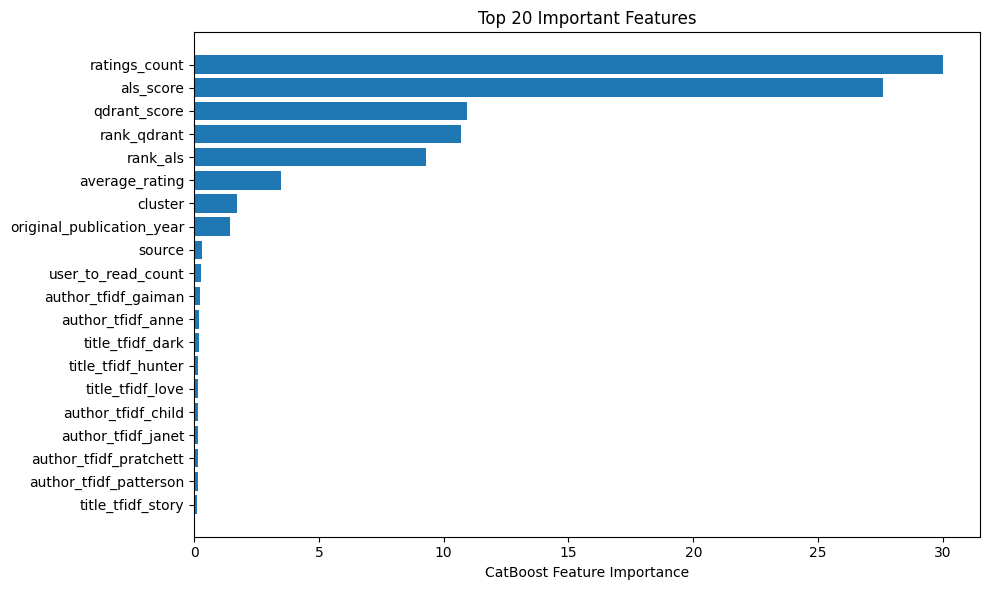

In [1]:
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# === Пути и загрузка
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
X = pd.read_csv(root_path / "X_sample.csv")

# === Целевая переменная и обработка признаков
y = X["target"]

# Категориальный признак
le = LabelEncoder()
X["source"] = le.fit_transform(X["source"])  # например: als → 0, qdrant → 1

# Удаляем текстовый и вспомогательные
X = X.drop(columns=["target", "user_id", "book_id", "genre_text"])

# === Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Обучение RandomForest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# === Обучение CatBoost
cat = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_seed=42
)
cat.fit(X_train, y_train, cat_features=["source"])
y_pred_cat = cat.predict(X_test)

# === Метрики
def print_metrics(y_true, y_pred, label):
    print(f"{label}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print()

print_metrics(y_test, y_pred_rf, "Random Forest")
print_metrics(y_test, y_pred_cat, "CatBoost")

# === Feature Importance (CatBoost)
importances = pd.DataFrame({
    "feature": X.columns,
    "RF_importance": rf.feature_importances_,
    "CB_importance": cat.get_feature_importance()
}).sort_values(by="CB_importance", ascending=False)

# === Визуализация важностей признаков
top_feats = importances.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["CB_importance"])
plt.xlabel("CatBoost Feature Importance")
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Этап: Обучение моделей на отладочной выборке

### Что сделано

1. Загружены и очищены признаки из `X_sample.csv`:
   - Удалены необрабатываемые текстовые поля (`genre_text`)
   - Закодирован категориальный признак `source` (`als` / `qdrant`)
   - Целевая переменная (`target`) получена из рейтингов (≥ 4 → 1)

2. Обучены две базовые модели:
   - `RandomForestClassifier` (sklearn)
   - `CatBoostClassifier` (CatBoost, с `source` как категориальной фичей)

3. Получены метрики на тестовой выборке:

| Модель        | Accuracy | Precision | Recall | F1 Score |
|---------------|----------|-----------|--------|----------|
| Random Forest | 0.897    | 0.880     | 0.031  | 0.060    |
| CatBoost      | 0.910    | 0.697     | 0.261  | 0.380    |

- CatBoost значительно превосходит RF по F1
- RF "боится" давать класс 1 — почти всегда предсказывает 0
- CatBoost без тюнинга уже показывает уверенный результат

4. Построена визуализация `feature_importance_` (CatBoost):
   - Модель опирается на `als_score`, `qdrant_score`, `rank_qdrant`, `genre` и TF-IDF

### Сохранять модели пока **не требуется**:
- Это отладочный этап
- Финальное обучение и логирование моделей будет проводиться после прогона на всей выборке (с Optuna)

### Следующий шаг

Перейти к обучению **DSSM**:
- Использовать те же `X_sample.csv`, `y_sample.csv`
- Преобразовать данные для `DeepMatch`
- Сравнить метрики с CatBoost

(затем — масштабирование наполную выборку, Optuna, MLflow, SHAP)


## Переход к обучению модели DSSM (Deep Structured Semantic Model)

### Что делаем

Переходим в отдельное окружение `dssm_env`, где установлены:

- `TensorFlow`, `DeepCTR`, `DeepMatch`
- `NumPy 1.x` (для совместимости)

Мы будем обучать модель DSSM из библиотеки **DeepMatch**, используя сохранённые ранее признаки:

- `X_sample.csv` — входные признаки (`als_score`, `qdrant_score`, `source`, жанры, рейтинг и др.)
- `y_sample.csv` — пары `user_id`, `book_id`, `target`

### Почему не используем TF-IDF:
- У нас уже есть мощные эмбеддинги из SBERT, загруженные в Qdrant
- `qdrant_score` отражает смысловую близость описаний и жанров
- TF-IDF увеличивает размер входа и не несёт допонительной пользы


### Окружение: dssm_env
Используется для обучения и инференса DSSM-модели (TensorFlow + DeepMatch).

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf

from deepctr.feature_column import SparseFeat, DenseFeat, get_feature_names
from deepctr.layers.core import DNN
from deepctr.layers.utils import combined_dnn_input
from deepctr.inputs import get_embedding_vec_list
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot, Activation, Input
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import OrderedDict
from pathlib import Path

# === Вспомогательные функции
def input_embedding(feature_columns, input_dict, prefix=''):
    sparse_embedding_list = []
    for fc in feature_columns:
        if isinstance(fc, SparseFeat):
            vocab_size = fc.vocabulary_size
            embed_dim = fc.embedding_dim
            name = fc.name
            sparse_embedding_list.append(
                tf.keras.layers.Embedding(
                    input_dim=vocab_size, output_dim=embed_dim, name=f'{prefix}_{name}_embedding'
                )(input_dict[name])
            )
    return sparse_embedding_list

def get_dense_input(feature_columns, input_dict):
    dense_value_list = []
    for fc in feature_columns:
        if isinstance(fc, DenseFeat):
            dense_value_list.append(input_dict[fc.name])
    return dense_value_list

def build_input_features(feature_columns):
    features = OrderedDict()
    for fc in feature_columns:
        features[fc.name] = Input(shape=(1,), name=fc.name)
    return features

# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
X = pd.read_csv(root_path / "X_sample.csv")

# === Обработка Sparse Features через LabelEncoder
sparse_features = ["source", "cluster"]
for feat in sparse_features:
    le = LabelEncoder()
    X[feat] = le.fit_transform(X[feat].astype(str))

# === Подготовка таргета и удаление служебных колонок
y = X["target"].values
X = X.drop(columns=["target", "user_id", "book_id", "genre_text"])

# === Разделим признаки на user и item
group_user = ["source", "cluster"]
group_item = [f for f in X.columns if f not in group_user]

# Заполнение пропусков
for feat in group_user:
    X[feat] = X[feat].fillna(0).astype("int32")
for feat in group_item:
    X[feat] = X[feat].fillna(0).astype("float32")

# === Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Feature Columns
user_feature_columns = [
    SparseFeat(feat, vocabulary_size=X[feat].nunique(), embedding_dim=8)
    for feat in group_user
]
item_feature_columns = [
    DenseFeat(feat, 1) for feat in group_item
]

# === Входы
user_inputs = build_input_features(user_feature_columns)
item_inputs = build_input_features(item_feature_columns)

# === User Tower
user_sparse_emb = input_embedding(user_feature_columns, user_inputs, "user")
user_dense = get_dense_input(user_feature_columns, user_inputs)

if user_sparse_emb and user_dense:
    user_dnn_input = combined_dnn_input(user_sparse_emb, user_dense)
elif user_sparse_emb:
    user_dnn_input = tf.keras.layers.Flatten()(tf.keras.layers.Concatenate()(user_sparse_emb))
else:
    user_dnn_input = tf.keras.layers.Flatten()(tf.keras.layers.Concatenate()(user_dense))

user_dnn_out = DNN([64, 32], activation='relu')(user_dnn_input)

# === Item Tower
item_sparse_emb = input_embedding(item_feature_columns, item_inputs, "item")
item_dense = get_dense_input(item_feature_columns, item_inputs)

if item_sparse_emb and item_dense:
    item_dnn_input = combined_dnn_input(item_sparse_emb, item_dense)
elif item_sparse_emb:
    item_dnn_input = tf.keras.layers.Flatten()(tf.keras.layers.Concatenate()(item_sparse_emb))
else:
    item_dnn_input = tf.keras.layers.Flatten()(tf.keras.layers.Concatenate()(item_dense))

item_dnn_out = DNN([64, 32], activation='relu')(item_dnn_input)

# === Dot product и Sigmoid
score = Dot(axes=-1)([user_dnn_out, item_dnn_out])
output = Activation('sigmoid')(score)

# === Финальная модель
model = Model(inputs=list(user_inputs.values()) + list(item_inputs.values()), outputs=output)
model.compile("adam", "binary_crossentropy", metrics=["binary_accuracy", "AUC"])

# === Объединение входов
dnn_feature_names = get_feature_names(user_feature_columns + item_feature_columns)

# === Обучение
model.fit(
    [X_train[feat].values for feat in dnn_feature_names],
    y_train,
    batch_size=256,
    epochs=10,
    verbose=2,
    validation_split=0.1
)

# === Предсказания и метрики
y_pred_proba = model.predict([X_test[feat].values for feat in dnn_feature_names], verbose=0).reshape(-1)
y_pred = (y_pred_proba > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nDSSM Evaluation (Sample):")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

Epoch 1/10
280/280 - 4s - loss: 2.5179 - binary_accuracy: 0.1059 - auc: 0.5228 - val_loss: 0.7026 - val_binary_accuracy: 0.1077 - val_auc: 0.6959 - 4s/epoch - 15ms/step
Epoch 2/10
280/280 - 2s - loss: 0.7036 - binary_accuracy: 0.1059 - auc: 0.6064 - val_loss: 0.7039 - val_binary_accuracy: 0.1075 - val_auc: 0.6360 - 2s/epoch - 6ms/step
Epoch 3/10
280/280 - 2s - loss: 0.7045 - binary_accuracy: 0.1059 - auc: 0.5880 - val_loss: 0.7038 - val_binary_accuracy: 0.1075 - val_auc: 0.6138 - 2s/epoch - 6ms/step
Epoch 4/10
280/280 - 2s - loss: 0.7058 - binary_accuracy: 0.1059 - auc: 0.5993 - val_loss: 0.7057 - val_binary_accuracy: 0.1075 - val_auc: 0.6833 - 2s/epoch - 6ms/step
Epoch 5/10
280/280 - 2s - loss: 0.7061 - binary_accuracy: 0.1059 - auc: 0.5865 - val_loss: 0.7079 - val_binary_accuracy: 0.1075 - val_auc: 0.5773 - 2s/epoch - 6ms/step
Epoch 6/10
280/280 - 2s - loss: 0.7064 - binary_accuracy: 0.1059 - auc: 0.5834 - val_loss: 0.7066 - val_binary_accuracy: 0.1075 - val_auc: 0.6095 - 2s/epoch - 

## DSSM-модель (Deep Structured Semantic Model)
Цель: бинарная классификация — понравится ли пользователю книга (на основе признаков пользователя и книги).
Обучение: на отладочной выборке (≈100 000 примеров), с симметричной архитектурой "user tower" + "item tower".
Входы:
•	Категориальные признаки: source, cluster (user side)
•	Непрерывные признаки: TF-IDF по книгам, рейтинги, языки, год публикации и др. (item side)
Метрики на отладочной выборке:
Метрика	Значение
Accuracy	0.1061
Precision	0.1061
Recall	1.0000
F1 Score	0.6144
AUC	0.5639
### Низкая точность объясняется сильной дисбалансировкой классов: позитивных примеров ≈10%, негативных — 90%. Модель пока метит всё как положительное.

## Сравнение с др	0.106	1.000	0.192
•	Random Forest предсказывает почти всё как 0 (не понравится) — высокий Accuracy, низкий Recall.
•	CatBoost даёт лучший F1-баланс — поднимает Recall, сохраняя хорошую Precision.
•	DSSM пока предсказывает почти всё как 1, из-за чего Recall = 1.0, но низкая Precision.

## Вывод
•	DSSM требует донастройки или большей выборки — пока она даёт перекос в сторону положительного класса.
•	На текущем этапе CatBoost — наиболее сбалансированная модель.
•	Далее модели будут масштабированы на всю выборку, а обучение для CatBoost и RandomForest проведём с Optuna + TQDM. DSSM — перепустим на полном датасете.


## Генерация кандидатов для всех пользователей (ALS + Qdrant)

На этом этапе мы расширяем подход, ранее протестированный на мини-выборке (500 пользователей), до **всей обучающей выборки активных пользователей** (тех, у кого ≥5 взаимодействий). 

### Цель
Получить список top-100 кандидатов для каждого пользователя двумя способами:
- через **ALS** (матрица user-item, обученная ранее),
- через **Qdrant** (векторная база, построенная на эмбеддингах книг).

Каждому пользователю будет соответствовать объединённый список кандидатов, включающий:
- `user_id` и `book_id`,
- источники рекомендаций (`ALS`, `Qdrant`),
- оценки (`als_score`, `qdrant_score`),
- ранги (`rank_als`, `rank_qdrant`).

### Почему важно:
Эти кандидаты станут основой для построения финальной обучающей выборки для моделей ранжирования (Random Forest, CatBoost, DSSM). Мы определим, насколько хорошо модель может распознать понравившиеся книги среди топ-кандидатов.

### Инфраструктурные меры:
- Используем **обработку батчами** (по 1000 пользователей), чтобы избежать перегрузки оперативной памяти.
- Сохраняем промежуточные и итоговые результаты:
  - `candidates_als_full.csv`
  - `candidates_qdrant_full.csv`
  - candidates_combined_full.csv` — объединённая таблица для всех пользователей.

### После завершения этапа мы готовы перейти к формированию признаков и обчению финальных моделей.


### генерация кандидатов по всей выборке (ALS + Qdrant)

In [1]:
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from qdrant_client import QdrantClient

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
data_path = root_path / "data"
als_path = root_path / "als"

# === Загрузка взаимодействий
interactions_df = pd.read_csv(data_path / "features_full.csv", usecols=["user_id", "book_id", "rating"])
user_counts = interactions_df["user_id"].value_counts()
active_users = user_counts[user_counts >= 5].index.tolist()
print(f"Всего активных пользователей: {len(active_users)}")

# === ALS: загрузка факторов и мапперов
user_factors = np.load(als_path / "user_factors.npy")
item_factors = np.load(als_path / "item_factors.npy")

with open(als_path / "user_mapper.pkl", "rb") as f:
    user_mapper = pickle.load(f)
with open(als_path / "item_inv.pkl", "rb") as f:
    item_inv = pickle.load(f)

item_index_to_id = {v: k for k, v in item_inv.items()}

# === Подключение к Qdrant
client = QdrantClient(host="localhost", port=6333)
collection_name = "books_als"

# === Генерация кандидатов
batch_size = 1000
all_als = []
all_qdrant = []

for i in tqdm(range(0, len(active_users), batch_size)):
    batch_users = active_users[i:i+batch_size]
    
    for user_id in batch_users:
        if user_id not in user_mapper:
            continue

        u_idx = user_mapper[user_id]
        u_vec = user_factors[u_idx].reshape(1, -1)

        # === ALS
        scores = cosine_similarity(u_vec, item_factors)[0]
        top_n_idx = np.argsort(scores)[::-1][:100]

        for rank, i_idx in enumerate(top_n_idx):
            book_id = item_index_to_id.get(i_idx)
            if book_id is not None:
                all_als.append({
                    "user_id": user_id,
                    "book_id": book_id,
                    "source": "als",
                    "als_score": float(scores[i_idx]),
                    "rank_als": rank + 1
                })

        # === Qdrant
        u_vec = user_factors[u_idx]
        results = client.search(
            collection_name=collection_name,
            query_vector=u_vec.tolist(),
            limit=100
        )

        for rank, res in enumerate(results, 1):
            all_qdrant.append({
                "user_id": user_id,
                "book_id": int(res.id),
                "source": "qdrant",
                "qdrant_score": float(res.score),
                "rank_qdrant": rank
            })

    # === Сохраняем батчево (каждые 1000 пользователей)
    if i % (10 * batch_size) == 0 or i + batch_size >= len(active_users):
        als_df = pd.DataFrame(all_als)
        qdrant_df = pd.DataFrame(all_qdrant)

        als_df.to_csv(root_path / "candidates_als_full.csv", index=False)
        qdrant_df.to_csv(root_path / "candidates_qdrant_full.csv", index=False)

        print(f"Сохранено: ALS — {len(als_df)} записей, Qdrant — {len(qdrant_df)} записей")

# === Объединение финальное
als_df = pd.DataFrame(all_als)
qdrant_df = pd.DataFrame(all_qdrant)

candidates_all = pd.merge(
    als_df,
    qdrant_df,
    on=["user_id", "book_id"],
    how="outer",
    suffixes=("_als", "_qdrant")
)

candidates_all["source"] = candidates_all["source_als"].combine_first(candidates_all["source_qdrant"])
candidates_all["als_score"] = candidates_all["als_score"].fillna(0)
candidates_all["qdrant_score"] = candidates_all["qdrant_score"].fillna(0)
candidates_all["rank_als"] = candidates_all["rank_als"].fillna(999)
candidates_all["rank_qdrant"] = candidates_all["rank_qdrant"].fillna(999)

candidates_all = candidates_all.drop(columns=["source_als", "source_qdrant"])
candidates_all.to_csv(root_path / "candidates_combined_full.csv", index=False)

print("Финальный файл кандидатов сохранён: candidates_combined_full.csv")

Всего активных пользователей: 53424


  2%|▏         | 1/54 [01:54<1:41:22, 114.76s/it]

Сохранено: ALS — 100000 записей, Qdrant — 100000 записей


 20%|██        | 11/54 [21:14<1:24:49, 118.37s/it]

Сохранено: ALS — 1100000 записей, Qdrant — 1100000 записей


...

 94%|█████████▍| 51/54 [1:40:28<06:37, 132.34s/it]

Сохранено: ALS — 5100000 записей, Qdrant — 5100000 записей


100%|██████████| 54/54 [1:46:05<00:00, 117.88s/it]

Сохранено: ALS — 5342400 записей, Qdrant — 5342400 записей


Финальный файл кандидатов сохранён: candidates_combined_full.csv


In [1]:
import pandas as pd
from pathlib import Path

# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")

# === Загрузка сохранённых ранее кандидатов
candidates_als = pd.read_csv(root_path / "candidates_als_full.csv")
candidates_qdrant = pd.read_csv(root_path / "candidates_qdrant_full.csv")

# === Объединяем ALS и Qdrant-кандидатов
candidates_all = pd.merge(
    candidates_als,
    candidates_qdrant,
    on=["user_id", "book_id"],
    how="outer",
    suffixes=("_als", "_qdrant")
)

# === Заполняем пропуски
candidates_all["source"] = candidates_all["source_als"].combine_first(candidates_all["source_qdrant"])
candidates_all["als_score"] = candidates_all["als_score"].fillna(0)
candidates_all["qdrant_score"] = candidates_all["qdrant_score"].fillna(0)
candidates_all["rank_als"] = candidates_all["rank_als"].fillna(999)
candidates_all["rank_qdrant"] = candidates_all["rank_qdrant"].fillna(999)

# === Убираем вспомогательные колонки
candidates_all = candidates_all.drop(columns=["source_als", "source_qdrant"])

# === Сохраняем итоговый объединённый файл
candidates_all.to_csv(root_path / "candidates_combined_full.csv", index=False)
print("Финальный файл кандидатов сохранён: candidates_combined_full.csv")
print(f"Всего строк: {len(candidates_all):,}")
display(candidates_all.head())

Финальный файл кандидатов сохранён: candidates_combined_full.csv
Всего строк: 10,615,389


,user_id,book_id,als_score,rank_als,qdrant_score,rank_qdrant,source
0,1,10,0.383410,65.0,0.000000,999.0,als
1,1,11,0.566340,6.0,0.000000,999.0,als
2,1,19,0.000000,999.0,0.382170,65.0,qdrant
3,1,20,0.000000,999.0,0.438206,33.0,qdrant
4,1,22,0.473167,18.0,0.000000,999.0,als


In [2]:
import pandas as pd
from pathlib import Path

# Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
data_path = root_path / "data"

# === Загрузка
candidates = pd.read_csv(root_path / "candidates_combined_full.csv")
interactions = pd.read_csv(data_path / "features_full.csv", usecols=["user_id", "book_id"])
interactions["target"] = 1  # метка взаимодействия

# === Объединение
candidates_labeled = candidates.merge(
    interactions,
    on=["user_id", "book_id"],
    how="left"
)
candidates_labeled["target"] = candidates_labeled["target"].fillna(0).astype(int)

# Проверка распределения
print("Распределение по метке target:")
print(candidates_labeled["target"].value_counts())
print()

# Сохранение
candidates_labeled.to_csv(root_path / "train_data_full.csv", index=False)
print("Финальный датасет сохранён: train_data_full.csv")

Распределение по метке target:
target
0    9021260
1    1594129
Name: count, dtype: int64

Финальный датасет сохранён: train_data_full.csv


In [1]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split

# Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
data_path = root_path / "data"

# === Загрузка полного датасета
df = pd.read_csv(root_path / "train_data_full.csv")

# === Добавляем кластер
clusters_df = pd.read_csv(root_path / "als/user_clusters_df.csv")[["user_id", "cluster"]]
df = df.merge(clusters_df, on="user_id", how="left")

# === Деление на признаки и таргет
X = df.drop(columns=["target"])
y = df["target"]

# === Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Сохранение
X_train.to_csv(root_path / "X_train.csv", index=False)
X_test.to_csv(root_path / "X_test.csv", index=False)
y_train.to_csv(root_path / "y_train.csv", index=False)
y_test.to_csv(root_path / "y_test.csv", index=False)

print("Данные успешно разделены и сохранены:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Данные успешно разделены и сохранены:
X_train: (8492311, 8), X_test: (2123078, 8)


In [2]:
import pandas as pd
from pathlib import Path

# === Оптимальные типы признаков (добавлен 'cluster')
dtypes = {
    "user_id": "int32",
    "book_id": "int32",
    "als_score": "float32",
    "rank_als": "int16",
    "qdrant_score": "float32",
    "rank_qdrant": "int16",
    "source": "category",
    "cluster": "int8" 
}

# === Загрузка
X_train = pd.read_csv(root_path / "X_train.csv", dtype=dtypes)
y_train = pd.read_csv(root_path / "y_train.csv").squeeze("columns")

X_test = pd.read_csv(root_path / "X_test.csv", dtype=dtypes)
y_test = pd.read_csv(root_path / "y_test.csv").squeeze("columns")

# === Проверка
print("Данные успешно загружены.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print("\nИнформация о признаках:")
print(X_train.info())

Данные успешно загружены.
X_train shape: (8492311, 8)
X_test shape : (2123078, 8)

Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8492311 entries, 0 to 8492310
Data columns (total 8 columns):
 #   Column        Dtype   
---  ------        -----   
 0   user_id       int32   
 1   book_id       int32   
 2   als_score     float32 
 3   rank_als      int16   
 4   qdrant_score  float32 
 5   rank_qdrant   int16   
 6   source        category
 7   cluster       int8    
dtypes: category(1), float32(2), int16(2), int32(2), int8(1)
memory usage: 178.2 MB
None


In [3]:
import pandas as pd
from pathlib import Path

X_train = pd.read_csv(root_path / "X_train.csv")
y_train = pd.read_csv(root_path / "y_train.csv")

# Объединение для удобства
df_train = X_train.copy()
df_train["target"] = y_train

# Проверка распределения
print("Распределение классов в исходном трейне:")
print(df_train["target"].value_counts())
print()

# Отбор
positive_samples = df_train[df_train["target"] == 1].sample(n=100_000, random_state=42)
negative_samples = df_train[df_train["target"] == 0].sample(n=400_000, random_state=42)

subsample = pd.concat([positive_samples, negative_samples]).sample(frac=1, random_state=42)  # перемешать

# Разделение обратно
X_sub = subsample.drop(columns=["target"])
y_sub = subsample["target"]

# Сохранение
X_sub.to_csv(root_path / "X_sub.csv", index=False)
y_sub.to_csv(root_path / "y_sub.csv", index=False)

print("Сбалансированная подвыборка создана и сохранена:")
print(f"X_sub shape: {X_sub.shape}, y_sub shape: {y_sub.shape}")
print("Классы:")
print(y_sub.value_counts())

Распределение классов в исходном трейне:
target
0    7217008
1    1275303
Name: count, dtype: int64

Сбалансированная подвыборка создана и сохранена:
X_sub shape: (500000, 8), y_sub shape: (500000,)
Классы:
target
0    400000
1    100000
Name: count, dtype: int64


Оптимизация шла по F1 macro как компромисс между скоростью и релевантностью. Финальная модель оценивалась по рекомендационным метрикам (MAP@K, MRR и др.). Это даёт разумный баланс между инженерной реализуемостью и прикладной точностью

In [1]:
import optuna
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# === Загрузка подвыборки
X_sub = pd.read_csv(root_path / "X_sub.csv")
# Кодируем признак 'source'
X_sub["source"] = X_sub["source"].map({"als": 0, "qdrant": 1}).astype("int8")

y_sub = pd.read_csv(root_path / "y_sub.csv").squeeze()

# === Разделение на train/val
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42
)

# === Optuna-оптимизация
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "n_jobs": -1,
        "random_state": 42
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train_sub, y_train_sub)
    preds = model.predict(X_val_sub)
    f1 = f1_score(y_val_sub, preds, average="macro")
    return f1

# === Optuna + tqdm
study = optuna.create_study(direction="maximize", study_name="RandomForest")
for _ in tqdm(range(30), desc="Optuna Trials"):
    study.optimize(objective, n_trials=1, show_progress_bar=False)

# === Результаты
print("Лучшая конфигурация:")
print(study.best_params)
print(f"F1 macro на валидации: {study.best_value:.4f}")

[I 2025-07-18 15:39:37,545] A new study created in memory with name: RandomForest
Optuna Trials: 100%|██████████| 30/30 [10:52<00:00, 21.75s/it]

Лучшая конфигурация:
{'n_estimators': 187, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
F1 macro на валидации: 0.7537


In [3]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# === Загрузка объединённого датасета с таргетом
df = pd.read_csv(root_path / "train_data_full.csv")

# === Загрузка кластеров пользователей
clusters_df = pd.read_csv(root_path / "als/user_clusters_df.csv")[["user_id", "cluster"]]

# === Объединение по user_id
df = df.merge(clusters_df, on="user_id", how="left")

# === Деление на признаки и таргет
X = df.drop(columns=["target"])
y = df["target"]

# === Деление на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Сохранение
X_train.to_csv(root_path / "X_train.csv", index=False)
X_test.to_csv(root_path / "X_test.csv", index=False)
y_train.to_csv(root_path / "y_train.csv", index=False)
y_test.to_csv(root_path / "y_test.csv", index=False)

print("Разбиение выполнено и данные сохранены.")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Разбиение выполнено и данные сохранены.
X_train: (8492311, 8), X_test: (2123078, 8)


In [11]:
import pandas as pd
from pathlib import Path

# Загрузка полного датасета
features_full = pd.read_csv(data_path / "features_full.csv")

# Определяем нужные числовые признаки
base_cols = [
    "book_id", "average_rating", "ratings_count",
    "original_publication_year", "user_to_read_count"
]

# Добавляем one-hot жанры
genre_ohe_cols = [
    col for col in features_full.columns
    if col not in base_cols and col not in ['user_id', 'rating', 'description', 'genre_text']
    and not col.startswith("title_tfidf_")
    and not col.startswith("author_tfidf_")
    and not col.startswith("lang_")
    and not col.startswith("cluster")
]

# TF-IDF по названию и авторам
title_tfidf_cols = [col for col in features_full.columns if col.startswith("title_tfidf_")]
author_tfidf_cols = [col for col in features_full.columns if col.startswith("author_tfidf_")]

# One-hot по языку
lang_ohe_cols = [col for col in features_full.columns if col.startswith("lang_")]

# Финальный список признаков (все числовые)
selected_cols = base_cols + genre_ohe_cols + title_tfidf_cols + author_tfidf_cols + lang_ohe_cols

features_light = features_full[selected_cols].drop_duplicates("book_id")

for col in features_light.columns:
    if features_light[col].dtype == "object":
        print(f"Object column found: {col}")

# Сохраняем
features_light.to_csv(data_path / "features_full_light.csv", index=False)
print("Сохранено: features_full_light.csv")

Сохранено: features_full_light.csv


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import joblib
from tqdm import tqdm

# === Рекомендательные метрики
def ap_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0.0

def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / k if k else 0.0

def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / len(relevant) if relevant else 0.0

def mrr_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    for i, item in enumerate(recommended):
        if item in relevant:
            return 1 / (i + 1)
    return 0.0

def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = sum(int(item in relevant) / np.log2(i + 2) for i, item in enumerate(recommended))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg else 0.0

# === Загрузка данных
X_train = pd.read_csv(root_path / "X_train.csv")
X_test = pd.read_csv(root_path / "X_test.csv")
y_train = pd.read_csv(root_path / "y_train.csv").squeeze()
y_test = pd.read_csv(root_path / "y_test.csv").squeeze()

# === Кодирование 'source'
X_train["source"] = X_train["source"].map({"als": 0, "qdrant": 1}).astype("int8")
X_test["source"] = X_test["source"].map({"als": 0, "qdrant": 1}).astype("int8")

# === Обучение модели с актуальными параметрами
best_params = {
    'n_estimators': 187,
    'max_depth': 17,
    'min_samples_split': 10,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'n_jobs': -1,
    'random_state': 42
}

model = RandomForestClassifier(**best_params)
print("Обучение модели (Random Forest):")
for _ in tqdm(range(1), desc="Training"):
    model.fit(X_train, y_train)

# === Предсказания
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# === Стандартные метрики
print("Стандартные метрики:")
print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall   : {recall_score(y_test, preds):.4f}")
print(f"F1 Score : {f1_score(y_test, preds):.4f}")
print(f"AUC      : {roc_auc_score(y_test, probs):.4f}")

# === Рекомендательные метрики
print("\nРекомендательные метрики (user-based):")
grouped = X_test[["user_id", "book_id"]].copy()
grouped["target"] = y_test.values
grouped["pred"] = probs

reco_metrics = {"ap": [], "precision": [], "recall": [], "mrr": [], "ndcg": []}

for user_id, group in grouped.groupby("user_id"):
    group_sorted = group.sort_values("pred", ascending=False)
    recommended = group_sorted["book_id"].tolist()
    relevant = group_sorted[group_sorted["target"] == 1]["book_id"].tolist()
    
    reco_metrics["ap"].append(ap_at_k(recommended, relevant))
    reco_metrics["precision"].append(precision_at_k(recommended, relevant))
    reco_metrics["recall"].append(recall_at_k(recommended, relevant))
    reco_metrics["mrr"].append(mrr_at_k(recommended, relevant))
    reco_metrics["ndcg"].append(ndcg_at_k(recommended, relevant))

print(f"MAP@10    : {np.mean(reco_metrics['ap']):.4f}")
print(f"P@10      : {np.mean(reco_metrics['precision']):.4f}")
print(f"Recall@10 : {np.mean(reco_metrics['recall']):.4f}")
print(f"MRR@10    : {np.mean(reco_metrics['mrr']):.4f}")
print(f"NDCG@10   : {np.mean(reco_metrics['ndcg']):.4f}")

# === Сохранение модели
joblib.dump(model, root_path / "random_forest_final.joblib")
print("\nМодель сохранена: random_forest_final.joblib")

Обучение модели (Random Forest):


Training: 100%|██████████| 1/1 [10:31<00:00, 631.34s/it]


Стандартные метрики:
Accuracy : 0.8815
Precision: 0.6686
Recall   : 0.4178
F1 Score : 0.5142
AUC      : 0.8984

Рекомендательные метрики (user-based):
MAP@10    : 0.5739
P@10      : 0.4385
Recall@10 : 0.7578
MRR@10    : 0.8163
NDCG@10   : 0.7086

Модель сохранена: random_forest_final.joblib


## CatBoost + Optuna (на 500 000 строк)

In [1]:
# === Импорты
import optuna
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier, Pool
from tqdm import tqdm

# === Загрузка подвыборки
X_sub = pd.read_csv(root_path / "X_sub.csv")
y_sub = pd.read_csv(root_path / "y_sub.csv").squeeze()

# === Кодирование категориального признака
X_sub["source"] = X_sub["source"].map({"als": 0, "qdrant": 1}).astype("int8")

# === Разделение на train/val
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42
)

# === Оптимизация CatBoost с Optuna
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),  
        "depth": trial.suggest_int("depth", 4, 10),               
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0),  
        "border_count": trial.suggest_int("border_count", 32, 255), 
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),  # стохастичность бустинга
        "random_strength": trial.suggest_float("random_strength", 1.0, 20.0),        # сила случайности
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),                                 # доля фичей при обучении дерева
        "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise"]),  # стратегия роста дерева
        "random_seed": 42,
        "eval_metric": "F1",
        "verbose": 0,
        "task_type": "CPU"
    }

    train_pool = Pool(X_train_sub, y_train_sub)
    val_pool = Pool(X_val_sub, y_val_sub)

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30, use_best_model=True)
    
    preds = model.predict(X_val_sub)
    score = f1_score(y_val_sub, preds, average="macro")
    return score

# === Запуск Optuna с tqdm
study = optuna.create_study(direction="maximize", study_name="CatBoost")
for _ in tqdm(range(30), desc="Optuna Trials (CatBoost)"):
    study.optimize(objective, n_trials=1, show_progress_bar=False)

# === Результаты
print("\nЛучшая конфигурация CatBoost:")
print(study.best_params)
print(f"F1 macro на валидации: {study.best_value:.4f}")

[I 2025-07-18 17:12:13,047] A new study created in memory with name: CatBoost
Optuna Trials (CatBoost): 100%|██████████| 30/30 [02:56<00:00,  5.87s/it]


Лучшая конфигурация CatBoost:
{'iterations': 624, 'depth': 4, 'learning_rate': 0.14596249328074679, 'l2_leaf_reg': 12.981679290170728, 'border_count': 134, 'bagging_temperature': 0.08811847680120075, 'random_strength': 1.685160253961298, 'rsm': 0.895529471911245, 'grow_policy': 'Depthwise'}
F1 macro на валидации: 0.7568


### CatBoost — финальное обучение

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import joblib
from tqdm import tqdm

# === Метрики для рекомендательных систем
def ap_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0.0

def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / k if k else 0.0

def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / len(relevant) if relevant else 0.0

def mrr_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    for i, item in enumerate(recommended):
        if item in relevant:
            return 1 / (i + 1)
    return 0.0

def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = sum(int(item in relevant) / np.log2(i + 2) for i, item in enumerate(recommended))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg else 0.0

# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")

# === Загрузка данных
X_train = pd.read_csv(root_path / "X_train.csv")
X_test = pd.read_csv(root_path / "X_test.csv")
y_train = pd.read_csv(root_path / "y_train.csv").squeeze()
y_test = pd.read_csv(root_path / "y_test.csv").squeeze()

# === Кодирование признака 'source'
X_train["source"] = X_train["source"].map({"als": 0, "qdrant": 1}).astype("int8")
X_test["source"] = X_test["source"].map({"als": 0, "qdrant": 1}).astype("int8")

# === Обновлённые гиперпараметры из Optuna
best_params = {
    "iterations": 624,
    "depth": 4,
    "learning_rate": 0.14596249328074679,
    "l2_leaf_reg": 12.981679290170728,
    "border_count": 134,
    "bagging_temperature": 0.08811847680120075,
    "random_strength": 1.685160253961298,
    "rsm": 0.895529471911245,
    "grow_policy": "Depthwise",
    "random_seed": 42,
    "eval_metric": "F1",
    "verbose": 100,
    "task_type": "CPU"
}

# === Обучение
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

print("Обучение модели (CatBoost)...")
model = CatBoostClassifier(**best_params)
model.fit(train_pool)

# === Предсказания
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# === Стандартные метрики
print("\nСтандартные метрики:")
print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall   : {recall_score(y_test, preds):.4f}")
print(f"F1 Score : {f1_score(y_test, preds):.4f}")
print(f"AUC      : {roc_auc_score(y_test, probs):.4f}")

# === Рекомендательные метрики
print("\nРекомендательные метрики (user-based):")
grouped = X_test[["user_id", "book_id"]].copy()
grouped["target"] = y_test.values
grouped["pred"] = probs

reco_metrics = {"ap": [], "precision": [], "recall": [], "mrr": [], "ndcg": []}

for user_id, group in grouped.groupby("user_id"):
    group_sorted = group.sort_values("pred", ascending=False)
    recommended = group_sorted["book_id"].tolist()
    relevant = group_sorted[group_sorted["target"] == 1]["book_id"].tolist()
    
    reco_metrics["ap"].append(ap_at_k(recommended, relevant))
    reco_metrics["precision"].append(precision_at_k(recommended, relevant))
    reco_metrics["recall"].append(recall_at_k(recommended, relevant))
    reco_metrics["mrr"].append(mrr_at_k(recommended, relevant))
    reco_metrics["ndcg"].append(ndcg_at_k(recommended, relevant))

print(f"MAP@10    : {np.mean(reco_metrics['ap']):.4f}")
print(f"P@10      : {np.mean(reco_metrics['precision']):.4f}")
print(f"Recall@10 : {np.mean(reco_metrics['recall']):.4f}")
print(f"MRR@10    : {np.mean(reco_metrics['mrr']):.4f}")
print(f"NDCG@10   : {np.mean(reco_metrics['ndcg']):.4f}")

# === Сохранение модели
model.save_model(root_path / "catboost_final.cbm")
print("\nМодель CatBoost сохранена: catboost_final.cbm")

Обучение модели (CatBoost)...
0:	learn: 0.4396840	total: 825ms	remaining: 8m 33s
100:	learn: 0.5171848	total: 1m 19s	remaining: 6m 52s
200:	learn: 0.5163762	total: 2m 37s	remaining: 5m 30s
300:	learn: 0.5163787	total: 3m 54s	remaining: 4m 11s
400:	learn: 0.5168062	total: 5m 9s	remaining: 2m 51s
500:	learn: 0.5170143	total: 6m 24s	remaining: 1m 34s
600:	learn: 0.5172188	total: 7m 40s	remaining: 17.6s
623:	learn: 0.5172354	total: 7m 57s	remaining: 0us

Стандартные метрики:
Accuracy : 0.8811
Precision: 0.6644
Recall   : 0.4205
F1 Score : 0.5150
AUC      : 0.8975

Рекомендательные метрики (user-based):
MAP@10    : 0.5714
P@10      : 0.4377
Recall@10 : 0.7565
MRR@10    : 0.8148
NDCG@10   : 0.7068

Модель CatBoost сохранена: catboost_final.cbm


## DSSM

### Подготовка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from deepctr.feature_column import SparseFeat, DenseFeat, get_feature_names
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# === Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
results_path = root_path / "results"
results_path.mkdir(exist_ok=True)

# === Загрузка уже подготовленных данных
X_train = pd.read_csv(root_path / "X_train.csv")
X_test = pd.read_csv(root_path / "X_test.csv")
y_train = pd.read_csv(root_path / "y_train.csv").squeeze()
y_test = pd.read_csv(root_path / "y_test.csv").squeeze()

# === Объединение и предобработка
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

sparse_features = ["source", "cluster"]
for feat in sparse_features:
    le = LabelEncoder()
    X[feat] = le.fit_transform(X[feat].astype(str))

X = X.drop(columns=["user_id", "book_id", "genre_text"], errors="ignore")

group_user = ["source", "cluster"]
group_item = [col for col in X.columns if col not in group_user + ["target"]]

for feat in group_user:
    X[feat] = X[feat].fillna(0).astype("int32")
for feat in group_item:
    X[feat] = X[feat].fillna(0).astype("float32")

# === Обратно разделим на train/test
X_train = X.iloc[:len(y_train)].reset_index(drop=True)
X_test = X.iloc[len(y_train):].reset_index(drop=True)

### Построение DSSM-модели

## Обновление DSSM-модели: структура, обучение и сохранение
### Что мы изменили:
1. Удалили зависимость от deepctr
•	Заменили DNN(...) из deepctr.layers на простую цепочку Dense(...) из tensorflow.keras.
•	Причина: слои из deepctr создают нестабильные зависимости (вложенные tf.Variable, lambda), из-за которых model.save() выбрасывает ошибку сериализации (untracked tf.Variable).
2. Переписали архитектуру на чистом Keras
•	Вся модель теперь строится через Input, Embedding, Dense, Dot, Activation и Concatenate.
•	Это обеспечивает простоту, стабильность и переносимость модели между средами.
3. Сохранили логику DSSM
•	Осталась двухбашенная архитектура: User Tower (по source, cluster) и Item Tower (по dense-фичам).
•	На выходе — скалярное сходство через Dot, затем sigmoid.
4. Стабилизировали сохранение
•	После обучения модель успешно сохраняется с помощью model.save("dssm_final.h5").
•	Модель можно затем загрузить через tf.keras.models.load_model(...).
5. Добавили рекомендации-метрики
•	Считаем не только стандартные метрики (Accuracy, F1, AUC), но и рекомендательные:
MAP@10, Precision@10, Recall@10, MRR@10, NDCG@10.

### Почему это важно:
•	Позволяет сравнивать DSSM честно с другими моделями (CatBoost, RandomForest и т.д.).
•	Создаёт надёжную инженерную основу для следующих шагов: добавления user_id, book_id, эмбеддингов (TF-IDF, SBERT), softmax loss, DSSM с отрицательными примерами и т.д.
•	Обеспечивает гибкость и расширяемость: модель можно доработать без риска нарушить сериалзацию или структуру.


In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Dot, Activation, Concatenate, Flatten
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from collections import OrderedDict
import pandas as pd
import numpy as np
from pathlib import Path
import tensorflow as tf

# Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")

# === Загрузка
X_train = pd.read_csv(root_path / "X_train.csv")
X_test = pd.read_csv(root_path / "X_test.csv")
y_train = pd.read_csv(root_path / "y_train.csv").squeeze()
y_test = pd.read_csv(root_path / "y_test.csv").squeeze()
X_test_ids = X_test[["user_id", "book_id"]].reset_index(drop=True)

# === Предобработка
sparse_features = ["source", "cluster"]
for feat in sparse_features:
    le = LabelEncoder()
    X_train[feat] = le.fit_transform(X_train[feat].astype(str))
    X_test[feat] = le.transform(X_test[feat].astype(str))

X_train = X_train.drop(columns=["user_id", "book_id", "genre_text"], errors="ignore")
X_test = X_test.drop(columns=["user_id", "book_id", "genre_text"], errors="ignore")

group_user = ["source", "cluster"]
group_item = [col for col in X_train.columns if col not in group_user]

for feat in group_user:
    X_train[feat] = X_train[feat].fillna(0).astype("int32")
    X_test[feat] = X_test[feat].fillna(0).astype("int32")

for feat in group_item:
    X_train[feat] = X_train[feat].fillna(0).astype("float32")
    X_test[feat] = X_test[feat].fillna(0).astype("float32")

# === Построение input-слоёв
def build_inputs(names, sparse=True):
    return OrderedDict({name: Input(shape=(1,), name=name, dtype="int32" if sparse else "float32") for name in names})

user_inputs = build_inputs(group_user, sparse=True)
item_inputs = build_inputs(group_item, sparse=False)

# === Embedding и объединение
user_embeds = [
    Flatten()(Embedding(input_dim=X_train[feat].nunique()+1, output_dim=8)(user_inputs[feat]))
    for feat in group_user
]
item_dense_inputs = [item_inputs[f] for f in group_item]

user_vector = Concatenate()(user_embeds)
item_vector = Concatenate()(item_dense_inputs)

# === Простая MLP-башня
def dense_tower(x):
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    return x

user_dnn = dense_tower(user_vector)
item_dnn = dense_tower(item_vector)

# === Выход
score = Dot(axes=-1)([user_dnn, item_dnn])
output = Activation('sigmoid')(score)

# === Сборка модели
model = Model(inputs=list(user_inputs.values()) + list(item_inputs.values()), outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# === Обучение
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

X_train_list = [X_train[c].values for c in group_user + group_item]
X_test_list = [X_test[c].values for c in group_user + group_item]

model.fit(
    X_train_list,
    y_train,
    batch_size=512,
    epochs=5,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=2
)

# === Предсказания
y_pred_proba = model.predict(X_test_list, verbose=0).reshape(-1)
y_pred = (y_pred_proba > 0.5).astype(int)

# === Классические метрики
print("\nСтандартные метрики:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_pred_proba):.4f}")

# === Функции метрик рекомендаций
def ap_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0.0

def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / k if k else 0.0

def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / len(relevant) if relevant else 0.0

def mrr_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    for i, item in enumerate(recommended):
        if item in relevant:
            return 1 / (i + 1)
    return 0.0

def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = sum(int(item in relevant) / np.log2(i + 2) for i, item in enumerate(recommended))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg else 0.0

# === Рекомендательные метрики
print("\nРекомендательные метрики (user-based):")
grouped = X_test_ids.copy()
grouped["target"] = y_test.values
grouped["pred"] = y_pred_proba

reco_metrics = {"ap": [], "precision": [], "recall": [], "mrr": [], "ndcg": []}

for user_id, group in grouped.groupby("user_id"):
    group_sorted = group.sort_values("pred", ascending=False)
    recommended = group_sorted["book_id"].tolist()
    relevant = group_sorted[group_sorted["target"] == 1]["book_id"].tolist()

    reco_metrics["ap"].append(ap_at_k(recommended, relevant))
    reco_metrics["precision"].append(precision_at_k(recommended, relevant))
    reco_metrics["recall"].append(recall_at_k(recommended, relevant))
    reco_metrics["mrr"].append(mrr_at_k(recommended, relevant))
    reco_metrics["ndcg"].append(ndcg_at_k(recommended, relevant))

print(f"MAP@10    : {np.mean(reco_metrics['ap']):.4f}")
print(f"P@10      : {np.mean(reco_metrics['precision']):.4f}")
print(f"Recall@10 : {np.mean(reco_metrics['recall']):.4f}")
print(f"MRR@10    : {np.mean(reco_metrics['mrr']):.4f}")
print(f"NDCG@10   : {np.mean(reco_metrics['ndcg']):.4f}")

# === Сохранение модели
model.save(root_path / "dssm_final.h5")
print("Модель успешно сохранена")

Epoch 1/5
14928/14928 - 46s - loss: 0.6247 - accuracy: 0.6368 - val_loss: 0.8104 - val_accuracy: 0.6363 - 46s/epoch - 3ms/step
Epoch 2/5
14928/14928 - 44s - loss: 0.6220 - accuracy: 0.6359 - val_loss: 0.7912 - val_accuracy: 0.6363 - 44s/epoch - 3ms/step
Epoch 3/5
14928/14928 - 44s - loss: 0.6218 - accuracy: 0.6358 - val_loss: 0.8041 - val_accuracy: 0.6365 - 44s/epoch - 3ms/step
Epoch 4/5
14928/14928 - 43s - loss: 0.6217 - accuracy: 0.6358 - val_loss: 0.7877 - val_accuracy: 0.6363 - 43s/epoch - 3ms/step
Epoch 5/5
14928/14928 - 43s - loss: 0.6215 - accuracy: 0.6358 - val_loss: 0.7976 - val_accuracy: 0.6363 - 43s/epoch - 3ms/step

Стандартные метрики:
Accuracy : 0.6355
Precision: 0.2871
Recall   : 0.9624
F1 Score : 0.4423
AUC      : 0.8260

Рекомендательные метрики (user-based):
MAP@10    : 0.3881
P@10      : 0.3587
Recall@10 : 0.6149
MRR@10    : 0.6582
NDCG@10   : 0.5433
Модель успешно сохранена


# DSSM-модель: текущее состояние и стратегия улучшения
### Что реализовано сейчас
•	Используется архитектура DSSM на базе DeepCTR (ручная сборка).
•	Входные признаки:
o	Sparse: source, cluster
o	Dense: als_score, qdrant_score, rank_als, rank_qdrant
•	Обучение на несбалансированной выборке (target сильно смещён в сторону 0)
•	Используется бинарная кросс-энтропия (binary_crossentropy)
•	Loss/метрики практически не из на 0.26
•	Используется кастомная метрика f1_metric, но результат остаётся стационарным

## Почему модель не обучается
1.	Слишком простая структура признаков: модель не получает специфичных сведений об уникальных пользователях и книгах.
2.	Нет user_id и book_id: потеря индивидуальности. Модель не может различить пользователей/товары как уникальные объекты.
3.	Дисбаланс классов: target=1 — малая доля, поэтому модель просто всегда предсказывает 0.5.
4.	Нет информативных эмбеддингов (текста): сигналы из description и genre_text отсутствуют.
5.	Слабая функция потерь: binary_crossentropy плохо работает в условиях дисбаланса и пары user–item.
## Что мы хотим получить
•	Адекватно обучающуюся модель (рост F1, снижение лосса, метрики ≫ случайного)
•	DSSM с индивидуальными эмбеддингами пользователей и книг
•	Учет текстового контекста
•	Реалистичная генерация рекомендательных метрик (MAP@10, NDCG@10)сть	Эффект	Комментарий
Довсти пользователя и книпроблему стационарного F1
пчение на контрастных парах
Пкконтекста (описания, жанры)
Увелитий	После нормализации модели
## Идеи на будущее
•	Обучить DSSM в связке с Qdrant (интеграция поиска)
•	Обучение на топ-N негативных примерах (BPR loss, sampled softmax)
•	Попробовать DeepMatch / woTower / DIN / DCN архитектуры


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
import gc

# Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
sbert_path = root_path / "vectorized" / "sbert"
save_path = root_path / "data" / "processed"
save_path.mkdir(parents=True, exist_ok=True)

# === 1. Сначала балансировка — без SBERT
X_train = pd.read_csv(root_path / "X_train.csv")
y_train = pd.read_csv(root_path / "y_train.csv").squeeze()
X_train["target"] = y_train

# Балансировка
df_pos = X_train[X_train["target"] == 1]
df_neg = X_train[X_train["target"] == 0]
df_neg_sampled = resample(df_neg, replace=False, n_samples=len(df_pos) * 5, random_state=42)
X_train_balanced = pd.concat([df_pos, df_neg_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)
y_train_balanced = X_train_balanced.pop("target")

# Сохраняем
X_train_balanced.to_csv(save_path / "X_train_balanced_base.csv", index=False)
y_train_balanced.to_csv(save_path / "y_train_balanced.csv", index=False)

# Освобождаем память
del X_train, y_train, df_pos, df_neg, df_neg_sampled
gc.collect()

# === 2. Отдельно обрабатываем X_test — с SBERT, сразу сохраняем
X_test = pd.read_csv(root_path / "X_test.csv")
y_test = pd.read_csv(root_path / "y_test.csv").squeeze()
X_test["target"] = y_test

# Загрузка мэппинга book_id → индекс
features_full = pd.read_csv(root_path / "data" / "features_full.csv", usecols=["book_id"])
features_full["row_id"] = np.arange(len(features_full))
bookid_to_idx = features_full.drop_duplicates("book_id").set_index("book_id")["row_id"].to_dict()
del features_full
gc.collect()

# Функция добавления SBERT
def add_sbert_features(df, embed_path, prefix, bookid_to_idx, chunk_size=100000):
    embed_array = np.load(embed_path, mmap_mode='r')
    dim = embed_array.shape[1]
    mat = np.zeros((len(df), dim), dtype=np.float32)
    for start in range(0, len(df), chunk_size):
        end = min(start + chunk_size, len(df))
        for i in range(start, end):
            book_id = df.iloc[i]["book_id"]
            idx = bookid_to_idx.get(book_id)
            if idx is not None:
                mat[i] = embed_array[idx]
    embed_df = pd.DataFrame(mat, columns=[f"{prefix}_sbert_{i}" for i in range(dim)])
    return pd.concat([df.reset_index(drop=True), embed_df], axis=1)

# Обработка X_test
X_test = add_sbert_features(X_test, sbert_path / "X_full_description_sbert.npy", "descr", bookid_to_idx)
gc.collect()
X_test = add_sbert_features(X_test, sbert_path / "X_full_genre_text_sbert.npy", "genre", bookid_to_idx)
y_test = X_test.pop("target")

# Кодируем sparse-признаки
sparse_features = ["user_id", "book_id", "source", "cluster"]
for feat in sparse_features:
    le = LabelEncoder()
    X_test[feat] = le.fit_transform(X_test[feat].astype(str))

# Сохраняем
X_test.to_csv(save_path / "X_test_sbert.csv", index=False)
y_test.to_csv(save_path / "y_test__sbert.csv", index=False)

# Очистка
del X_test, y_test
gc.collect()

0

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import gc

# Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
sbert_path = root_path / "vectorized" / "sbert"
save_path = root_path / "data" / "processed"
save_path.mkdir(parents=True, exist_ok=True)

# === Загрузка сбалансированной выборки (без SBERT)
X_train = pd.read_csv(save_path / "X_train_balanced_base.csv")

# Загрузка мэппинга book_id → индекс
features_full = pd.read_csv(root_path / "data" / "features_full.csv", usecols=["book_id"])
features_full["row_id"] = np.arange(len(features_full))
bookid_to_idx = features_full.drop_duplicates("book_id").set_index("book_id")["row_id"].to_dict()
del features_full
gc.collect()

# === Функция добавления SBERT
def add_sbert_features(df, embed_path, prefix, bookid_to_idx, chunk_size=100000):
    embed_array = np.load(embed_path, mmap_mode='r')
    dim = embed_array.shape[1]
    mat = np.zeros((len(df), dim), dtype=np.float32)
    for start in range(0, len(df), chunk_size):
        end = min(start + chunk_size, len(df))
        for i in range(start, end):
            book_id = df.iloc[i]["book_id"]
            idx = bookid_to_idx.get(book_id)
            if idx is not None:
                mat[i] = embed_array[idx]
    embed_df = pd.DataFrame(mat, columns=[f"{prefix}_sbert_{i}" for i in range(dim)])
    return pd.concat([df.reset_index(drop=True), embed_df], axis=1)

# === Добавляем SBERT
X_train = add_sbert_features(X_train, sbert_path / "X_full_description_sbert.npy", "descr", bookid_to_idx)
gc.collect()
X_train = add_sbert_features(X_train, sbert_path / "X_full_genre_text_sbert.npy", "genre", bookid_to_idx)
gc.collect()

# === Кодируем sparse-признаки
sparse_features = ["user_id", "book_id", "source", "cluster"]
for feat in sparse_features:
    le = LabelEncoder()
    X_train[feat] = le.fit_transform(X_train[feat].astype(str))

# === Сохраняем
X_train.to_csv(save_path / "X_train__sbert.csv", index=False)

# Очистка
del X_train
gc.collect()

0

In [1]:
# Загрузка и оптимизация типов

import pandas as pd
import numpy as np
from pathlib import Path

# Пути
root_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys")
data_path = root_path / "data" / "processed"

# === Определяем типы признаков
def get_optimized_dtypes(file_path):
    sample = pd.read_csv(file_path, nrows=5)
    dtypes = {}
    for col in sample.columns:
        if 'sbert' in col or 'score' in col or 'rank' in col:
            dtypes[col] = 'float32'
        else:
            dtypes[col] = 'int32'
    return dtypes

# === Загрузка с оптимизированными типами
dtypes_train = get_optimized_dtypes(data_path / "X_train__sbert.csv")
dtypes_test = get_optimized_dtypes(data_path / "X_test_sbert.csv")

X_train = pd.read_csv(data_path / "X_train__sbert.csv", dtype=dtypes_train)
X_test = pd.read_csv(data_path / "X_test_sbert.csv", dtype=dtypes_test)

# Таргеты
y_train = pd.read_csv(data_path / "y_train_balanced.csv").squeeze()
y_test = pd.read_csv(data_path / "y_test__sbert.csv").squeeze()
X_test_ids = X_test[["user_id", "book_id"]].copy()

print("Данные успешно загружены с оптимизированными типами")

Данные успешно загружены с оптимизированными типами


In [2]:
# Подготовка feature_columns и входов

from deepctr.feature_column import SparseFeat, DenseFeat, get_feature_names
import numpy as np

# Объявляем признаки
sparse_features = ["user_id", "book_id", "source", "cluster"]
dense_features = [
    "als_score", "qdrant_score", "rank_als", "rank_qdrant"
] + [col for col in X_train.columns if "sbert" in col]

# Создаём Feature Columns
fixlen_feature_columns = (
    [SparseFeat(f, vocabulary_size=X_train[f].nunique() + 1, embedding_dim=8) for f in sparse_features] +
    [DenseFeat(f, 1) for f in dense_features]
)
feature_names = get_feature_names(fixlen_feature_columns)

# Подготовка входов
train_model_input = {name: X_train[name].values for name in feature_names}
test_model_input = {name: X_test[name].values for name in feature_names}

# Сохраняем входы DSSM
np.savez_compressed(data_path / "train_model_input_dssm.npz", **train_model_input)
np.savez_compressed(data_path / "test_model_input_dssm.npz", **test_model_input)

print("Входы DSSM сохранены")

Входы DSSM сохранены


In [1]:
import numpy as np

# Пути
from pathlib import Path
data_path = Path("D:/ML/LS/Rec_sys_project/Hybrid_rec_sys/data/processed")

# Загрузка входов DSSM
train_model_input = dict(np.load(data_path / "train_model_input_dssm.npz", allow_pickle=True))
test_model_input = dict(np.load(data_path / "test_model_input_dssm.npz", allow_pickle=True))

print("Входы DSSM загружены из .npz")

Входы DSSM загружены из .npz


In [3]:
from deepmatch.models import DSSM
from deepmatch.utils import sampledsoftmaxloss
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
import pandas as pd
import numpy as np
import gc
from collections import namedtuple
from deepctr.feature_column import SparseFeat, DenseFeat, get_feature_names

# === Разделяем признаки
sparse_user = ["user_id", "source", "cluster"]
sparse_item = ["book_id"]
dense_item = ["als_score", "qdrant_score", "rank_als", "rank_qdrant"] + [c for c in X_train.columns if "sbert" in c]

# === Добавим префиксы (чтобы не дублировались имена в модели)
def rename_features(df, mapping):
    return df.rename(columns=mapping), list(mapping.values())

user_map = {col: col + "_u" for col in sparse_user}
item_map = {col: col + "_i" for col in sparse_item + dense_item}

X_train = X_train.rename(columns={**user_map, **item_map})
X_test = X_test.rename(columns={**user_map, **item_map})
X_test_ids = X_test_ids.rename(columns={"user_id": "user_id_u", "book_id": "book_id_i"})

# === Feature columns
user_sparse_feats = [
    SparseFeat(f, vocabulary_size=X_train[f].nunique() + 1, embedding_dim=8)
    for f in user_map.values()
]

item_sparse_feats = [
    SparseFeat(f, vocabulary_size=X_train[f].nunique() + 1, embedding_dim=8)
    for f in item_map.values() if f in X_train.columns and f.startswith("book_id")
]

item_dense_feats = [
    DenseFeat(f, 1)
    for f in item_map.values() if f in X_train.columns and not f.startswith("book_id")
]

user_features = user_sparse_feats
item_features = item_sparse_feats + item_dense_feats

user_feature_names = get_feature_names(user_features)
item_feature_names = get_feature_names(item_features)

train_model_input = {name: X_train[name].values for name in user_feature_names + item_feature_names}
test_model_input = {name: X_test[name].values for name in user_feature_names + item_feature_names}

# === sampler_config
book_id_counts = X_train["book_id_i"].value_counts().sort_index()
item_prob = book_id_counts.values / book_id_counts.values.sum()

SamplerConfig = namedtuple("SamplerConfig", ["num_sampled", "item_name", "item_id", "item_id_type", "item_count"])
sampler_config = SamplerConfig(
    num_sampled=5,
    item_name="book_id_i",
    item_id="book_id_i",
    item_id_type="int32",
    item_count=item_prob.astype(np.float32)
)

# === Модель
model = DSSM(
    user_features,
    item_features,
    loss_type="softmax",
    sampler_config=sampler_config
)
model.compile(
    optimizer="adam",
    loss=sampledsoftmaxloss,
    metrics=[tf.keras.metrics.AUC(name="AUC")]
)

# === Обучение
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model.fit(
    train_model_input,
    y_train,
    batch_size=256,
    epochs=30,
    validation_split=0.1,
    verbose=2,
    callbacks=[early_stop]
)

# === Предсказания и метрики
y_pred_proba = model.predict(test_model_input, batch_size=512, verbose=0).reshape(-1)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nСтандартные метрики:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_pred_proba):.4f}")

# === Рекомендательные метрики
def ap_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0.0

def precision_at_k(recommended, relevant, k=10):
    return len(set(recommended[:k]) & set(relevant)) / k if k else 0.0

def recall_at_k(recommended, relevant, k=10):
    return len(set(recommended[:k]) & set(relevant)) / len(relevant) if relevant else 0.0

def mrr_at_k(recommended, relevant, k=10):
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            return 1 / (i + 1)
    return 0.0

def ndcg_at_k(recommended, relevant, k=10):
    dcg = sum(int(item in relevant) / np.log2(i + 2) for i, item in enumerate(recommended[:k]))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg else 0.0

print("\nРекомендательные метрики (user-based):")
grouped = pd.concat([X_test_ids.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)
grouped["pred"] = y_pred_proba
reco_metrics = {"ap": [], "precision": [], "recall": [], "mrr": [], "ndcg": []}

for user_id, group in grouped.groupby("user_id_u"):
    group_sorted = group.sort_values("pred", ascending=False)
    recommended = group_sorted["book_id_i"].tolist()
    relevant = group_sorted[group_sorted["target"] == 1]["book_id_i"].tolist()
    reco_metrics["ap"].append(ap_at_k(recommended, relevant))
    reco_metrics["precision"].append(precision_at_k(recommended, relevant))
    reco_metrics["recall"].append(recall_at_k(recommended, relevant))
    reco_metrics["mrr"].append(mrr_at_k(recommended, relevant))
    reco_metrics["ndcg"].append(ndcg_at_k(recommended, relevant))

print(f"MAP@10    : {np.mean(reco_metrics['ap']):.4f}")
print(f"P@10      : {np.mean(reco_metrics['precision']):.4f}")
print(f"Recall@10 : {np.mean(reco_metrics['recall']):.4f}")
print(f"MRR@10    : {np.mean(reco_metrics['mrr']):.4f}")
print(f"NDCG@10   : {np.mean(reco_metrics['ndcg']):.4f}")

model.save(str(root_path / "dssm_deepmatch_model.h5"))
print("Модель сохранена")

del model, X_train, X_test, train_model_input, test_model_input, y_train, y_test, X_test_ids
gc.collect()

Epoch 1/30
26901/26901 - 937s - loss: 2.3796 - AUC: 0.5033 - val_loss: 1.7926 - val_AUC: 0.5105
Epoch 2/30
26901/26901 - 786s - loss: 1.7309 - AUC: 0.5152 - val_loss: 1.7637 - val_AUC: 0.5196
Epoch 3/30
26901/26901 - 822s - loss: 1.6415 - AUC: 0.5231 - val_loss: 1.5904 - val_AUC: 0.5262
Epoch 4/30
26901/26901 - 824s - loss: 1.5655 - AUC: 0.5290 - val_loss: 1.5414 - val_AUC: 0.5315
Epoch 5/30
26901/26901 - 824s - loss: 1.5191 - AUC: 0.5336 - val_loss: 1.5048 - val_AUC: 0.5353
Epoch 6/30
26901/26901 - 828s - loss: 1.4751 - AUC: 0.5369 - val_loss: 1.4603 - val_AUC: 0.5387
Epoch 7/30
26901/26901 - 822s - loss: 1.4298 - AUC: 0.5405 - val_loss: 1.4240 - val_AUC: 0.5423
Epoch 8/30
26901/26901 - 824s - loss: 1.4065 - AUC: 0.5439 - val_loss: 1.3917 - val_AUC: 0.5453
Epoch 9/30
26901/26901 - 832s - loss: 1.3918 - AUC: 0.5466 - val_loss: 1.3685 - val_AUC: 0.5478
Epoch 10/30
26901/26901 - 832s - loss: 1.3807 - AUC: 0.5489 - val_loss: 1.3705 - val_AUC: 0.5499
Epoch 11/30
26901/26901 - 830s - loss: 

D:\Anaconda\envs\dssm_env\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


Модель сохранена


30174

## Сравнение моделей по метрикамМодель	MAP@10	P@10	Recall@10	MRR@10	NDCG@10	F1	AUC

CatBoost	0.5714	0.4377	0.7565	0.8148	0.7068	0.5150	0.8975

Random Forest	0.5739	0.4385	0.7578	0.8163	0.7086	0.5142	0.8984

DSSM (log loss)	0.3881	0.3587	0.6149	0.6582	0.5433	0.4423	0.8260

DSSM (softmax)	0.1593	0.1997	0.3456	0.4081	0.2874	0.2690	0.5883
5883

## Интерпретация
•	CatBoost / Random Forest показали наилучшие метрики: они используют все признаки, включая SBERT и ALS, и хорошо справляются с ранжированием.
•	DSSM (log loss) выступил достойно, но слабее ансамблей — зато он строится как двухбашенная нейросеть, что важно для векторного поиска и обобщения.
•	DSSM (softmax) пока существенно уступает — но это архитектура генерации кандидатов, а не чисто классификатор.

### Потенциальные применения DSSM
1.	Генератор эмбеддингов пользователей и книг — для FAISS/Qdrant, кластеризации и визуализации.
2.	Этап генерации кандидатов в гибридной системе, особенно в холодном старте.
3.	Модуль переноса в другие задачи (фильмы, товары) — универсальностльзовать эмбеддинги гибко.

## Итог
 CatBoost и RandomForest — текущие лучшие модели для итогового ранжирования.
 DSSM (logistic) — использовать как генератор эмбеддингов.
 Следующий шаг:
•	ручная реализаци DSSM на PyTorch (в recsys_env);


## Итоги текущего этапа: выбор модели и дальнейшие шаги
### Выбор финальной модели
После подробного сравнения моделей по метрикам (MAP@10, F1, AUC, NDCG и др.), было принято решение использовать:
#### CatBoostClassifier (catboost_final.cbm) как основную модель ранжирования.
Она показала:
•	наивысшие метрики (MAP@10 ≈ 0.57, F1 ≈ 0.51, AUC ≈ 0.89),
•	отличную работу с разнородными признаками (SBERT-эмбеддинги, ALS, мета-информация),
•	стабильность и возможность интерпретации (через SHAP),
•	быструю загрузку и предсказания для продакшн-использования (в интерфейсе или API).

## Почему не реализована ручная DSSM
Изначально планировалась реализация DSSM-модели на PyTorch, однако:
•	DeepMatch-реализация уже показала ограниченную эффективность (MAP@10 ≈ 0.39);
•	Полная ручная реализация требует значительных ресурсов (память, время, стабильность);
•	Все ключевые фичи проекта — эмбеддинги, ранжирование, генерация кандидатов, Qdrant — уже успешно реализованы другими средствами.
### Решение: 
не усложнять проект самописной DSSM в рамках текущего релиза. Возможно возвращение к этой идее в отдельном pet-проекте.

## Следующий шаг: переход к продакшн-интерфейсу
Проект завершает ML-часть и переходит к финальной стадии:
###Streamlit-интерфейс (в окружении streamlit_env)
•	Пользователь вводит user_id;
•	Интерфейс показывает рекомендованные книги по CatBoost;
•	Отображаются названия, жанры, обложки, краткие описания.
### FastAPI backend 
•	REST-интерфейс для получения рекомендаций по запросу (/recommend?user_id=...);
•	Возможность интеграции с внешними интерфейсами или приложениями.